In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings("ignore")
#Plotting style
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})
PALETTE = {0: "#4C9BE8", 1: "#E84C4C"}   # blue = no default, red = default

In [4]:
url = 'https://raw.githubusercontent.com/Arfrost/Home-Credit-Default-Risk/main/data/processed/final_merged.parquet'

df = pd.read_parquet(url)
display(df.head())

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,...,cc_avg_drawings,cc_avg_atm_drawings,cc_total_drawing_count,cc_max_dpd,cc_avg_dpd,cc_late_payment_count,cc_late_payment_rate,prev_approval_rate,overall_late_payment_rate,total_missed_payments,debt_to_income,annuity_to_income,credit_to_income,prev_credit_to_current,bur_debt_to_current_credit,late_payment_debt_burden,pos_avg_dpd_3m,pos_max_dpd_3m,pos_late_count_3m,pos_late_rate_3m,pos_avg_dpd_6m,pos_max_dpd_6m,pos_late_count_6m,pos_late_rate_6m,cc_avg_balance_3m,cc_avg_utilization_3m,cc_avg_dpd_3m,cc_max_dpd_3m,cc_late_count_3m,cc_late_rate_3m,cc_avg_balance_6m,cc_avg_utilization_6m,cc_avg_dpd_6m,cc_max_dpd_6m,cc_late_count_6m,cc_late_rate_6m,inst_avg_delay_1y,inst_max_delay_1y,inst_late_count_1y,inst_late_rate_1y
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.000000,0.0,1.213733,0.121978,2.007889,0.440374,0.604482,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-17.583334,-12.0,0.0,0.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.000000,0.0,0.000000,0.132217,4.790750,0.374326,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.000000,0.0,0.000000,0.100000,2.000000,0.148933,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,297000.0,Unaccompanied,Working,Secondary / secondary special,Civil marriage,House / apartment,0.008019,-19005,-3039,-9833.0,-2437,NaN,1,1,0,1,0,0,Laborers,2.0,2,2,WEDNESDAY,17,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.555556,0.000000,6.0,NaN,0.219900,2.316167,0.932881,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-6.181818,-1.0,0.0,0.0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,513000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.028663,-19932,-3038,-4311.0,-3458,NaN,1,1,0,1,0,0,Core staff,1.0,2,2,THURSDAY,11,0,0,0,0,1,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.079992,0.0,0.000000,0.179963,4.222222,0.324832,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,-3.615385,0.0,0.0,0.0


In [5]:
print("=" * 20)
print("DATASET OVERVIEW")
print("=" * 20)
print(f"Shape          : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage   : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(f"\nDtype breakdown:\n{df.dtypes.value_counts().to_string()}")

DATASET OVERVIEW
Shape          : 307,511 rows × 230 columns
Memory usage   : 343.5 MB

Dtype breakdown:
float32    173
int32       41
str         16


In [6]:
display(df.describe())

,SK_ID_CURR,TARGET,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,...,cc_avg_drawings,cc_avg_atm_drawings,cc_total_drawing_count,cc_max_dpd,cc_avg_dpd,cc_late_payment_count,cc_late_payment_rate,prev_approval_rate,overall_late_payment_rate,total_missed_payments,debt_to_income,annuity_to_income,credit_to_income,prev_credit_to_current,bur_debt_to_current_credit,late_payment_debt_burden,pos_avg_dpd_3m,pos_max_dpd_3m,pos_late_count_3m,pos_late_rate_3m,pos_avg_dpd_6m,pos_max_dpd_6m,pos_late_count_6m,pos_late_rate_6m,cc_avg_balance_3m,cc_avg_utilization_3m,cc_avg_dpd_3m,cc_max_dpd_3m,cc_late_count_3m,cc_late_rate_3m,cc_avg_balance_6m,cc_avg_utilization_6m,cc_avg_dpd_6m,cc_max_dpd_6m,cc_late_count_6m,cc_late_rate_6m,inst_avg_delay_1y,inst_max_delay_1y,inst_late_count_1y,inst_late_rate_1y
count,307511.000000,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,3.072330e+05,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,104582.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307509.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,134133.000000,3.068510e+05,246546.000000,151450.00000,127568.000000,157504.000000,103023.000000,92646.000000,143620.000000,152683.000000,154491.000000,...,2.910570e+05,291057.000000,291057.000000,291057.000000,291057.000000,291057.000000,291057.000000,291057.000000,291057.000000,291057.000000,263491.000000,307499.000000,307511.000000,291057.000000,263491.000000,2.495070e+05,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,3.075110e+05,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000,307511.000000
mean,278180.518577,0.080729,0.417052,1.687979e+05,5.990260e+05,27108.574219,5.383962e+05,0.020868,-16036.995067,63815.045904,-4986.120117,-2994.202373,12.061090,0.999997,0.819889,0.199368,0.998133,0.281066,0.056720,2.152665,2.052463,2.031521,12.063419,0.015144,0.050769,0.040659,0.078173,0.230454,0.179555,0.502130,5.143927e-01,0.510853,0.11744,0.088442,0.977735,0.752471,0.044621,0.078942,0.149725,0.226282,...,4.149733e+03,2577.985107,7.743964,4.752079,1.174396,0.442659,0.006015,0.748855,0.033824,2.115204,3.595340,0.180930,3.957570,0.412894,1.460444,4.757927e+04,4.332521,4.920718,0.015577,0.005351,4.715325,5.730767,0.034301,0.005758,2.099980e+04,0.074428,2.461277,2.542182,0.007935,0.003387,20110.187500,0.071674,2.744496,3.044304,0.018214,0.003536,-7.926455,-1.423452,0.606782,0.037189
std,102790.175348,0.272419,0.722121,2.371231e+05,4.024908e+05,14493.737305,3.694465e+05,0.013831,4363.988632,141275.766519,3522.886230,1509.450419,11.944812,0.001803,0.384280,0.399526,0.043164,0.449521,0.231307,0.910682,0.509034,0.502737,3.265832,0.122126,0.219526,0.197499,0.268444,0.421124,0.383817,0.211062,1.910602e-01,0.194844,0.10824,0.082438,0.059223,0.113280,0.076036,0.134576,0.100049,0.144641,...,1.587410e+04,11167.696289,30.854141,75.847610,23.560455,3.378393,0.042539,0.262332,0.056664,9.030599,8.046950,0.094574,2.689728,0.518208,4.118599,2.182640e+05,99.212631,110.334457,0.184550,0.061267,101.227783,117.905418,0.350047,0.058427,8.438835e+04,0.244606,60.701496,61.9

# TARGET DISTRIBUTION

  Repaid (0): 282,686 (91.93%)
  Default (1): 24,825 (8.07%)

  Class imbalance ratio (0:1) = 11.4:1


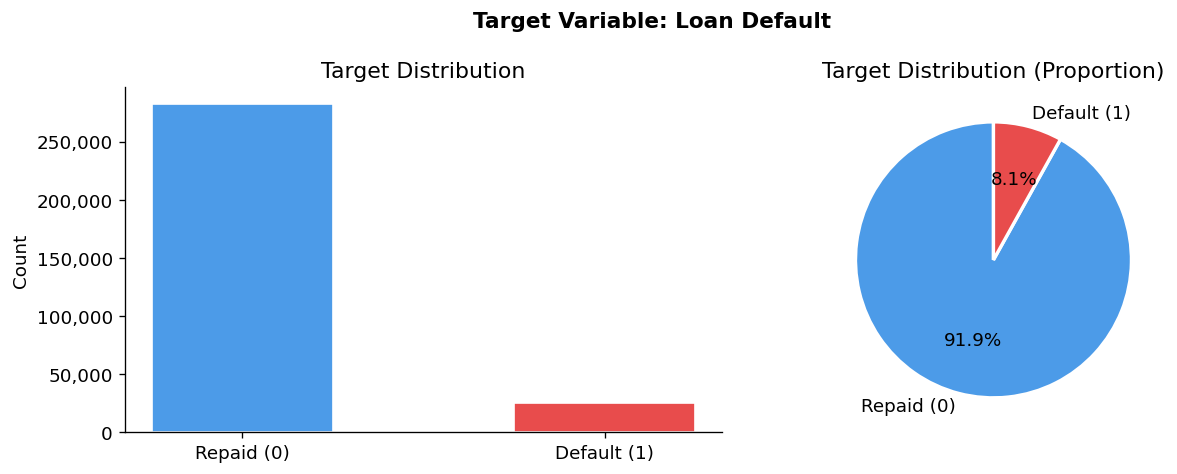

In [7]:
target_counts = df["TARGET"].value_counts().sort_index()
target_pct = df["TARGET"].value_counts(normalize=True).sort_index() * 100

for val, cnt, pct in zip(target_counts.index, target_counts, target_pct):
    label = "Repaid (0)" if val == 0 else "Default (1)"
    print(f"  {label}: {cnt:,} ({pct:.2f}%)")

imbalance_ratio = target_counts[0] / target_counts[1]
print(f"\n  Class imbalance ratio (0:1) = {imbalance_ratio:.1f}:1")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(["Repaid (0)", "Default (1)"], target_counts.values,
            color=[PALETTE[0], PALETTE[1]], edgecolor="white", width=0.5)
axes[0].set_title("Target Distribution")
axes[0].set_ylabel("Count")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

axes[1].pie(target_counts.values, labels=["Repaid (0)", "Default (1)"],
            colors=[PALETTE[0], PALETTE[1]],
            autopct="%1.1f%%", startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Target Distribution (Proportion)")

plt.suptitle("Target Variable: Loan Default", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

#Missing Values

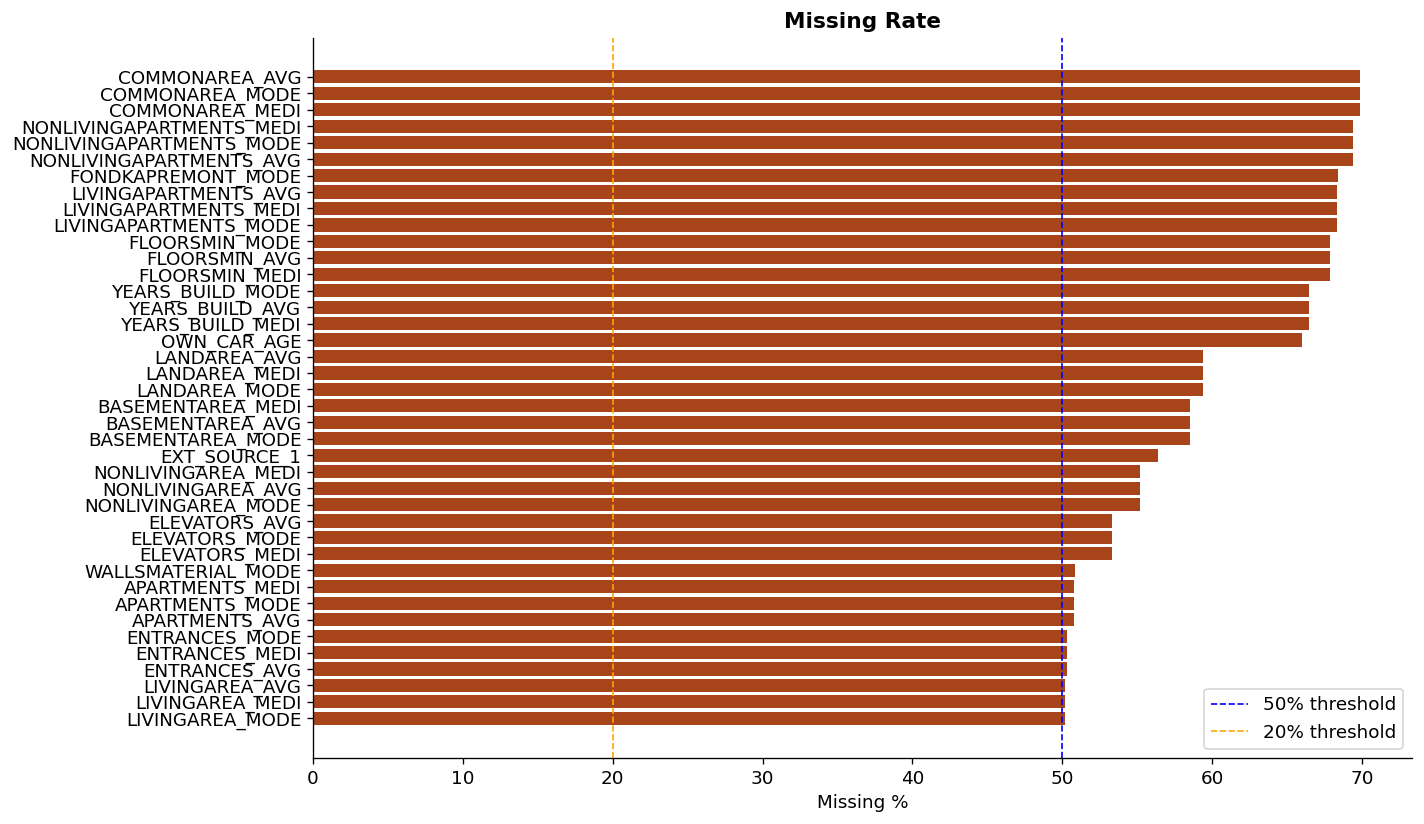

  Columns with any missing : 150 / 230
  Cols >50% missing        : 41
  Cols >20% missing        : 50
  Cols <5% missing         : 11

  Missingness by feature group (rows with ANY missing in group):
    building (AVG/MODE/MEDI)           : 225,918 rows (73.5%)
    bureau (bur_*)                     : 44,021 rows (14.3%)
    previous_app (prev_*)              : 33,907 rows (11.0%)
    pos_cash (pos_*)                   : 16,454 rows (5.4%)
    installments (inst_*)              : 16,454 rows (5.4%)
    credit_card (cc_*)                 : 16,454 rows (5.4%)


In [8]:
missing = df.isnull().sum()
missing_pct = missing / len(df) * 100
miss_df = pd.DataFrame({"missing_n": missing, "missing_pct": missing_pct})
miss_df = miss_df[miss_df["missing_n"] > 0].sort_values("missing_pct", ascending=False)


# Group-level missingness
groups = {
    "building (AVG/MODE/MEDI)": [c for c in df.columns if any(x in c for x in
        ["APARTMENTS","BASEMENTAREA","YEARS_BUILD","COMMONAREA",
         "ELEVATORS","FLOORS","LANDAREA","LIVINGAREA","NONLIVING","TOTALAREA"])],
    "bureau (bur_*)": [c for c in df.columns if c.startswith("bur_")],
    "previous_app (prev_*)": [c for c in df.columns if c.startswith("prev_")],
    "pos_cash (pos_*)": [c for c in df.columns if c.startswith("pos_")],
    "installments (inst_*)": [c for c in df.columns if c.startswith("inst_")],
    "credit_card (cc_*)": [c for c in df.columns if c.startswith("cc_")],
}

fig, ax = plt.subplots(figsize=(12, 7))
top_miss = miss_df.head(40)
colors = ["#a84419" if p > 50 else "#F4A261" if p > 20 else "#4C9BE8"
          for p in top_miss["missing_pct"]]
ax.barh(top_miss.index[::-1], top_miss["missing_pct"][::-1], color=colors[::-1])
ax.axvline(50, color="blue", linestyle="--", linewidth=1, label="50% threshold")
ax.axvline(20, color="orange", linestyle="--", linewidth=1, label="20% threshold")
ax.set_xlabel("Missing %")
ax.set_title("Missing Rate", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

print(f"  Columns with any missing : {len(miss_df)} / {df.shape[1]}")
print(f"  Cols >50% missing        : {(miss_df['missing_pct'] > 50).sum()}")
print(f"  Cols >20% missing        : {(miss_df['missing_pct'] > 20).sum()}")
print(f"  Cols <5% missing         : {(miss_df['missing_pct'] < 5).sum()}")

print("\n  Missingness by feature group (rows with ANY missing in group):")
for grp, cols in groups.items():
    if cols:
        miss_rows = df[cols].isnull().any(axis=1).sum()
        print(f"    {grp:35s}: {miss_rows:,} rows ({miss_rows/len(df)*100:.1f}%)")


#CATEGORICAL FEATURES

In [9]:
cat_cols_names = df.select_dtypes(include=['object', 'category']).columns

print("Number of Categorical Variables:", len(cat_cols_names))
print("List of Variables:\n", cat_cols_names.tolist())

Number of Categorical Variables: 16
List of Variables:
 ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE', 'EMERGENCYSTATE_MODE']



  NAME_CONTRACT_TYPE  (2 categories)
    Dominant: 'Cash loans' (90.5%)
    Default rate by category:
NAME_CONTRACT_TYPE
Cash loans         0.083459
Revolving loans    0.054783

  CODE_GENDER  (3 categories)
    Dominant: 'F' (65.8%)
    Default rate by category:
CODE_GENDER
M      0.101419
F      0.069993
XNA    0.000000

  FLAG_OWN_CAR  (2 categories)
    Dominant: 'N' (66.0%)
    Default rate by category:
FLAG_OWN_CAR
N    0.085002
Y    0.072437

  FLAG_OWN_REALTY  (2 categories)
    Dominant: 'Y' (69.4%)
    Default rate by category:
FLAG_OWN_REALTY
N    0.083249
Y    0.079616

  NAME_TYPE_SUITE  (7 categories)
    Dominant: 'Unaccompanied' (81.2%)
    Default rate by category:
NAME_TYPE_SUITE
Other_B            0.098305
Other_A            0.087760
Group of people    0.084871
Unaccompanied      0.081830
Spouse, partner    0.078716
Family             0.074946
Children           0.073768

  NAME_INCOME_TYPE  (8 categories)
    Dominant: 'Working' (51.6%)
    Default rate by category

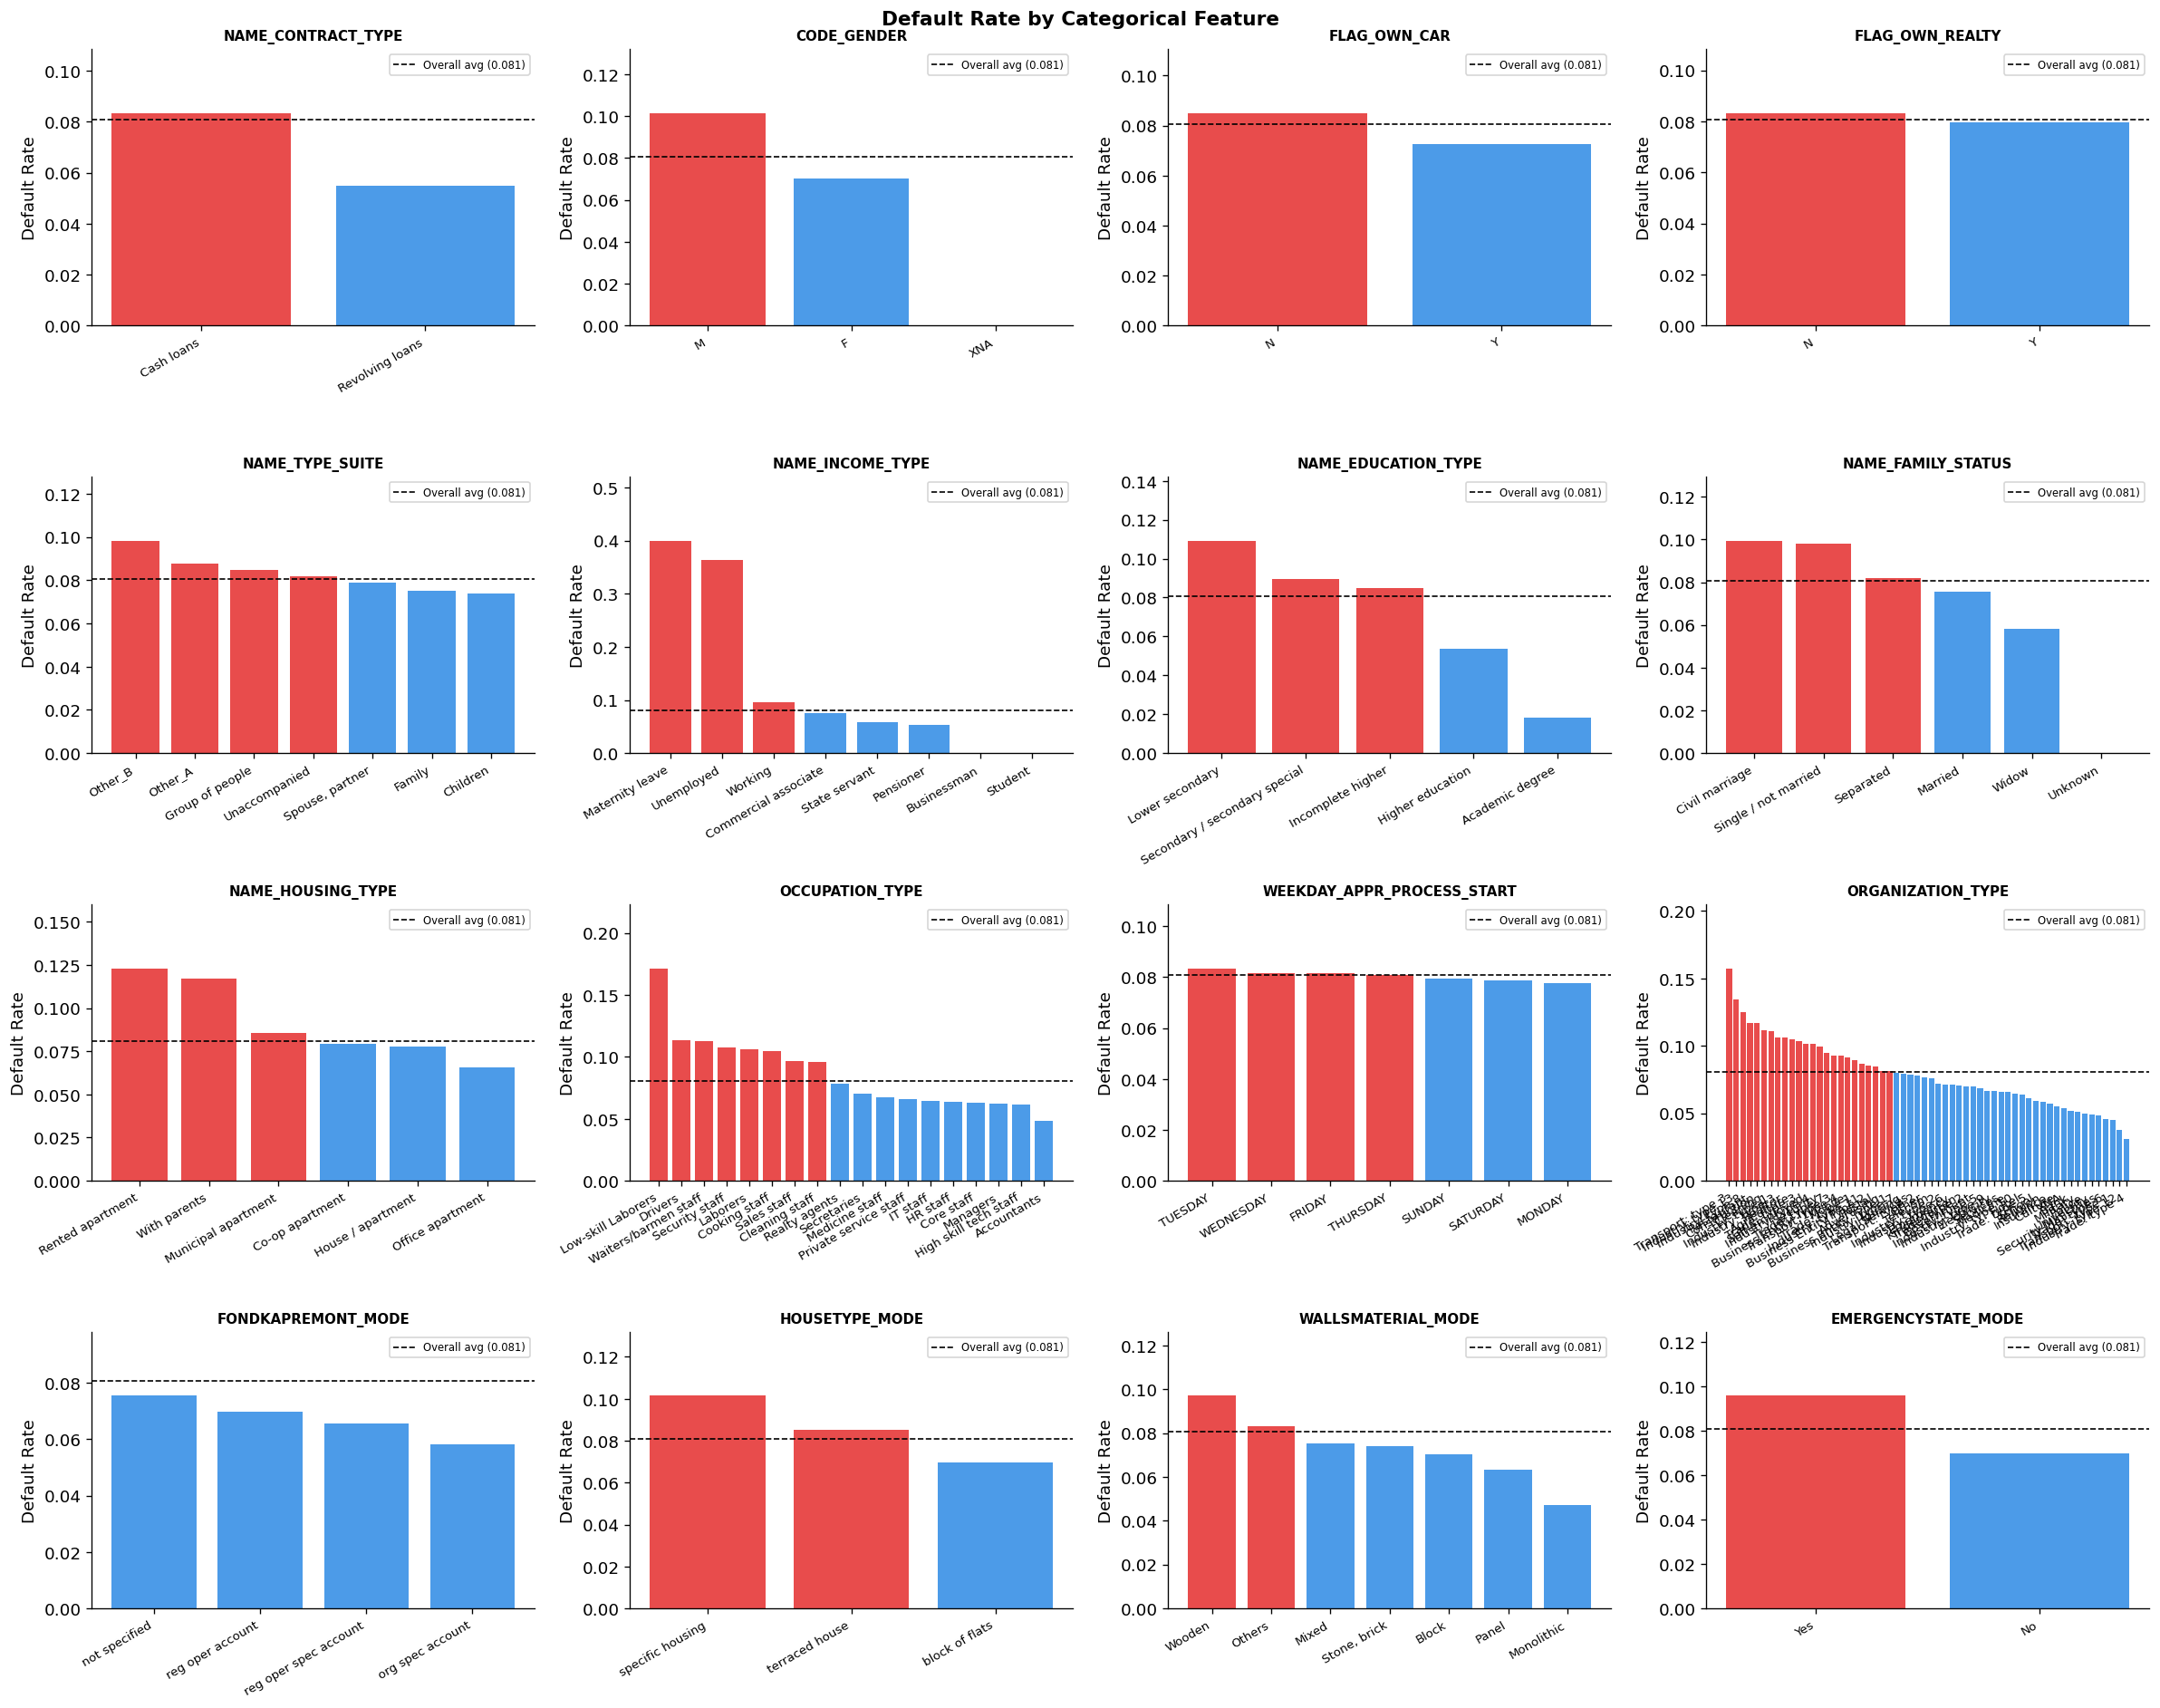

In [10]:
cat_cols = ["NAME_CONTRACT_TYPE", "CODE_GENDER", "FLAG_OWN_CAR",
            "FLAG_OWN_REALTY",'NAME_TYPE_SUITE', "NAME_INCOME_TYPE", "NAME_EDUCATION_TYPE",
            "NAME_FAMILY_STATUS", "NAME_HOUSING_TYPE", "OCCUPATION_TYPE",
            'WEEKDAY_APPR_PROCESS_START','ORGANIZATION_TYPE','FONDKAPREMONT_MODE', 'HOUSETYPE_MODE',
            'WALLSMATERIAL_MODE','EMERGENCYSTATE_MODE']

for col in cat_cols:
    n_unique = df[col].nunique()
    top = df[col].value_counts().index[0]
    top_pct = df[col].value_counts(normalize=True).iloc[0] * 100
    default_rates = df.groupby(col)["TARGET"].mean().sort_values(ascending=False)
    print(f"\n  {col}  ({n_unique} categories)")
    print(f"    Dominant: '{top}' ({top_pct:.1f}%)")
    print(f"    Default rate by category:\n{default_rates.to_string()}")

fig, axes = plt.subplots(4, 4, figsize=(20, 16)) # Changed to 4x4 grid and adjusted figsize
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    dr = df.groupby(col)["TARGET"].mean().sort_values(ascending=False)
    counts = df[col].value_counts().reindex(dr.index)
    ax = axes[i]
    bars = ax.bar(range(len(dr)), dr.values,
                  color=["#E84C4C" if v > df["TARGET"].mean() else "#4C9BE8"
                         for v in dr.values])
    ax.axhline(df["TARGET"].mean(), color="black", linestyle="--", linewidth=1,
               label=f"Overall avg ({df['TARGET'].mean():.3f})")
    ax.set_xticks(range(len(dr)))
    ax.set_xticklabels(dr.index, rotation=30, ha="right", fontsize=8)
    ax.set_title(col, fontsize=9, fontweight="bold")
    ax.set_ylabel("Default Rate")
    ax.set_ylim(0, min(dr.max() * 1.3, 1.0))
    ax.legend(fontsize=7)

plt.suptitle("Default Rate by Categorical Feature",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### CATEGORICAL INTERACTION (EDUCATION vs OCCUPATION)

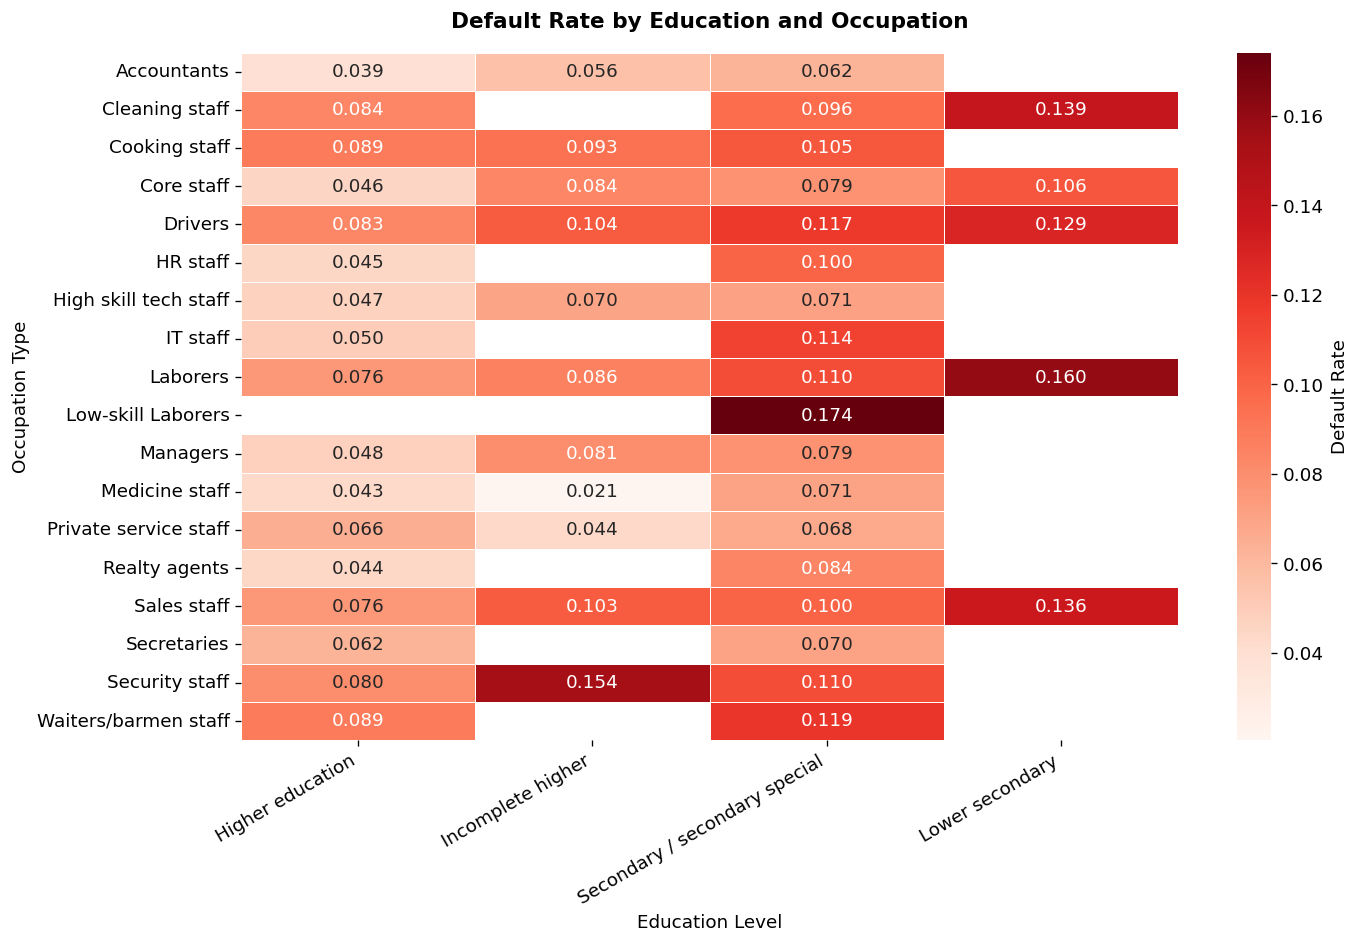

In [11]:
#we are including groups with at least 100 people to avoid misleading results
cross_dr = df.groupby(["OCCUPATION_TYPE", "NAME_EDUCATION_TYPE"])["TARGET"].agg(['mean', 'count'])
cross_dr = cross_dr[cross_dr['count'] > 100]['mean'].unstack()

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(cross_dr, cmap="Reds", annot=True, fmt=".3f",
            linewidths=0.5, cbar_kws={'label': 'Default Rate'}, ax=ax)
ax.set_title("Default Rate by Education and Occupation", fontsize=13, fontweight="bold", pad=15)
ax.set_xlabel("Education Level")
ax.set_ylabel("Occupation Type")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

#NUMERIC FEATURES

In [12]:
numeric_names = df.select_dtypes(include=['number']).columns

print("Number of Numeric Variables:", len(numeric_names))
print("List of Variables:\n", numeric_names.tolist())

Number of Numeric Variables: 214
List of Variables:
 ['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'OWN_CAR_AGE', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASE


  Mean values by target (0=repaid, 1=default):
    Age (years)                        : repaid=44.2142, default=40.7804
    Employment duration (years)        : repaid=6.6798, default=4.9724
    Annual Income                      : repaid=169077.7188, default=165611.7500
    Credit Amount                      : repaid=602648.2500, default=557778.5000
    Annuity Amount                     : repaid=27163.6230, default=26481.7441
    External Source 1                  : repaid=0.5115, default=0.3870
    External Source 2                  : repaid=0.5235, default=0.4109
    External Source 3                  : repaid=0.5210, default=0.3907
    Credit-to-Income Ratio             : repaid=3.9637, default=3.8874
    Annuity-to-Income Ratio            : repaid=0.1805, default=0.1855
    Debt-to-Income Ratio               : repaid=3.5590, default=4.0294
    Installment Late Payment Rate      : repaid=0.0730, default=0.1025


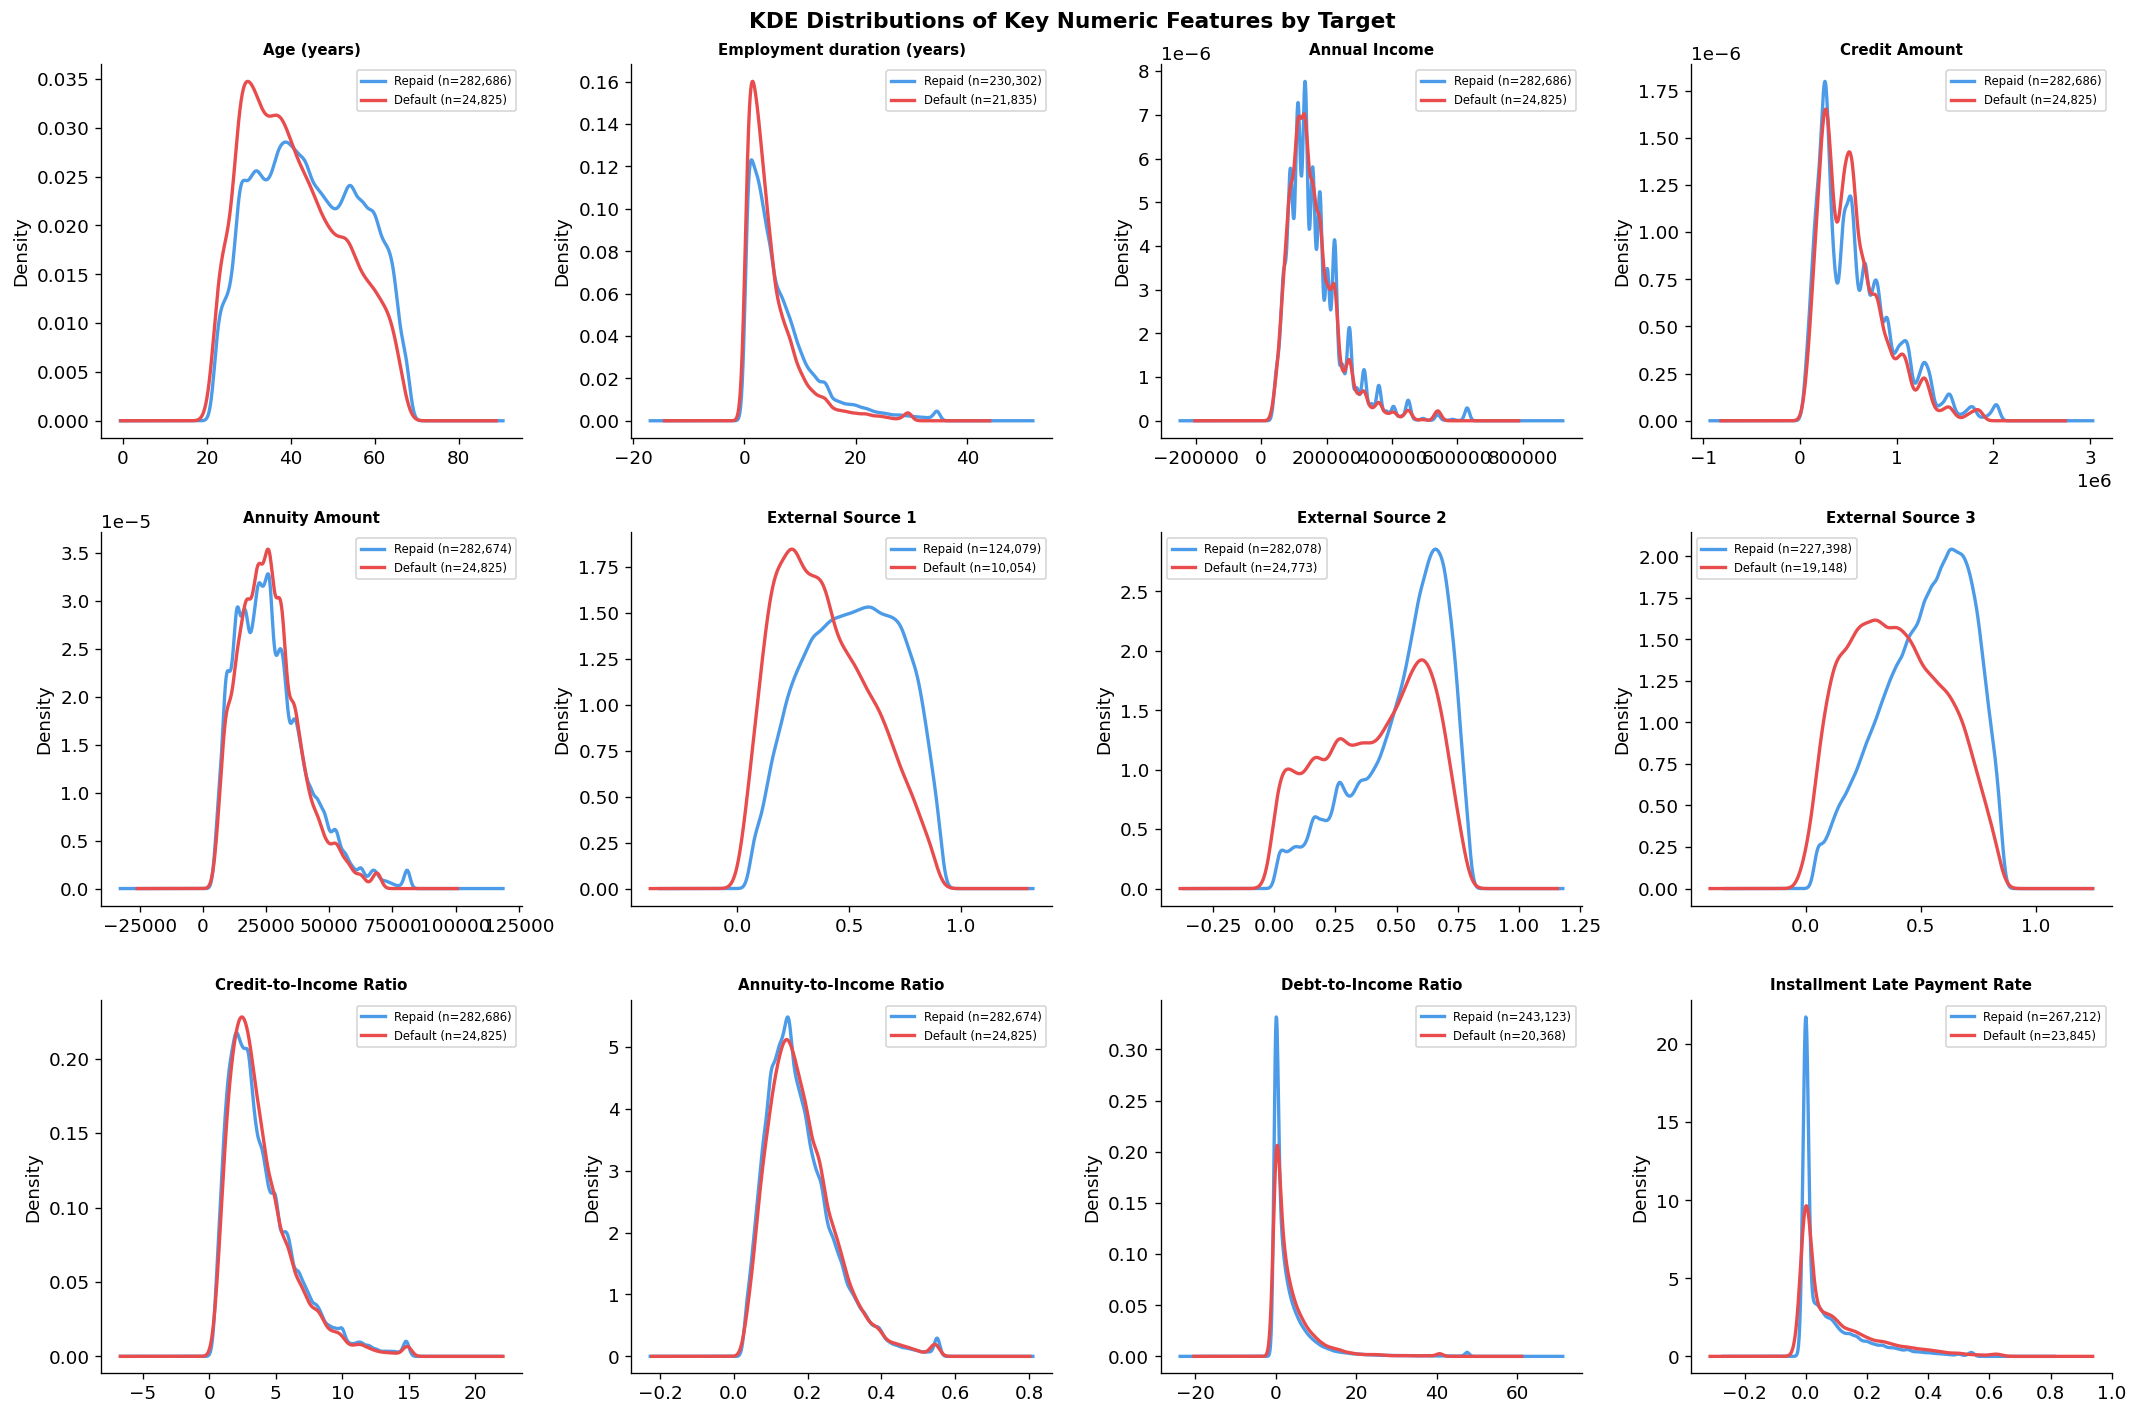

In [13]:
# Create derived features for readability
df["AGE_YEARS"] = -df["DAYS_BIRTH"] / 365
df["YEARS_EMPLOYED"] = np.where(
    df["DAYS_EMPLOYED"] == 365243, np.nan, -df["DAYS_EMPLOYED"] / 365
)

key_numeric = [
    ("AGE_YEARS", "Age (years)"),
    ("YEARS_EMPLOYED", "Employment duration (years)"),
    ("AMT_INCOME_TOTAL", "Annual Income"),
    ("AMT_CREDIT", "Credit Amount"),
    ("AMT_ANNUITY", "Annuity Amount"),
    ("EXT_SOURCE_1", "External Source 1"),
    ("EXT_SOURCE_2", "External Source 2"),
    ("EXT_SOURCE_3", "External Source 3"),
    ("credit_to_income", "Credit-to-Income Ratio"),
    ("annuity_to_income", "Annuity-to-Income Ratio"),
    ("debt_to_income", "Debt-to-Income Ratio"),
    ("inst_late_payment_rate", "Installment Late Payment Rate"),
]

print("\n  Mean values by target (0=repaid, 1=default):")
for col, label in key_numeric:
    if col in df.columns:
        g = df.groupby("TARGET")[col].mean()
        print(f"    {label:35s}: repaid={g.get(0, np.nan):.4f}, "
              f"default={g.get(1, np.nan):.4f}")

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, (col, label) in enumerate(key_numeric):
    if col not in df.columns:
        axes[i].set_visible(False)
        continue
    ax = axes[i]
    for tgt, color in PALETTE.items():
        data = df[df["TARGET"] == tgt][col].dropna()
        # clip extreme outliers for readability
        lo, hi = data.quantile(0.005), data.quantile(0.995)
        data = data.clip(lo, hi)
        data.plot.kde(ax=ax, color=color,
                      label=f"{'Repaid' if tgt==0 else 'Default'} (n={len(data):,})",
                      linewidth=2)
    ax.set_title(label, fontsize=9, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Density")
    ax.legend(fontsize=7)

plt.suptitle("KDE Distributions of Key Numeric Features by Target",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### BIVARIATE ANALYSIS: INCOME vs CREDIT AMOUNT

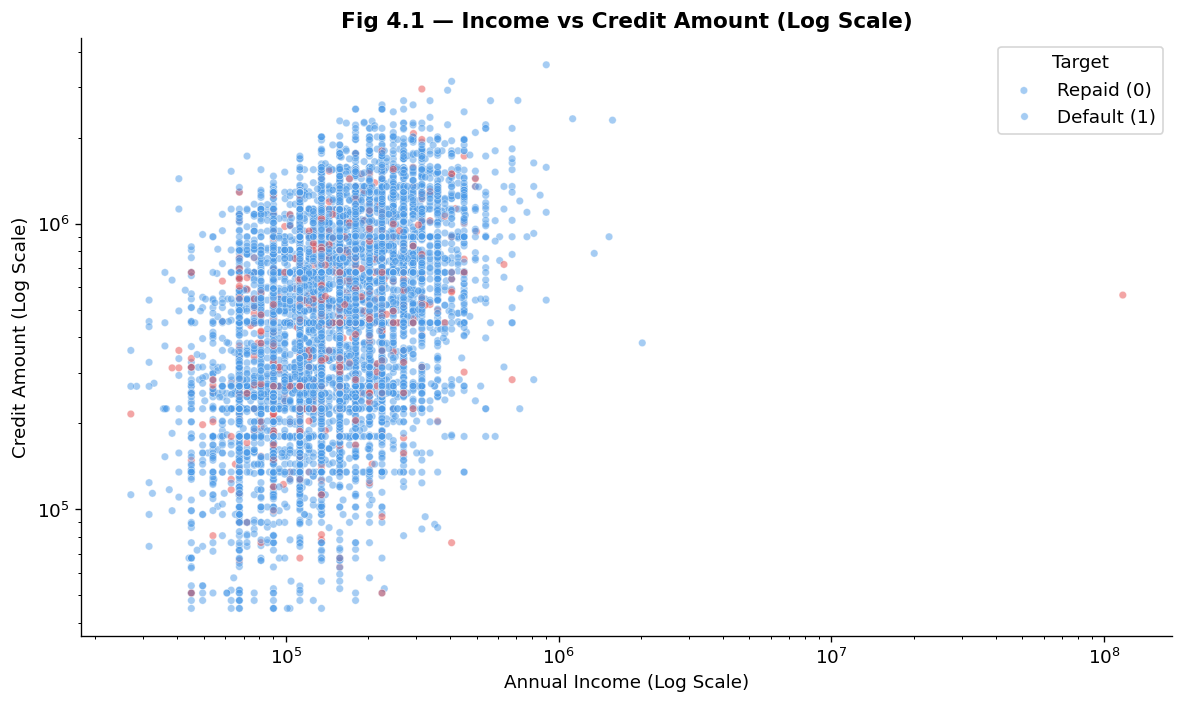

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))

#to keep the visualization from becoming too complex, we take a random sample of 10,000 data points
sample_df_vs = df.sample(n=min(10000, len(df)), random_state=42)

sns.scatterplot(data=sample_df_vs, x="AMT_INCOME_TOTAL", y="AMT_CREDIT",
                hue="TARGET", palette=PALETTE, alpha=0.5, s=20, ax=ax)

#Logarithmic axis (prevents outliers from distorting the graph)
ax.set_xscale("log")
ax.set_yscale("log")

ax.set_title("Fig 4.1 — Income vs Credit Amount (Log Scale)", fontsize=13, fontweight="bold")
ax.set_xlabel("Annual Income (Log Scale)")
ax.set_ylabel("Credit Amount (Log Scale)")
ax.legend(title="Target", labels=["Repaid (0)", "Default (1)"])

plt.tight_layout()
plt.show()

# EXTERNAL SOURCES


  Coverage:
    EXT_SOURCE_1: 134,133 (43.6%) not missing
    EXT_SOURCE_2: 306,851 (99.8%) not missing
    EXT_SOURCE_3: 246,546 (80.2%) not missing

  Correlation with TARGET:
    EXT_SOURCE_1: r = -0.1553
    EXT_SOURCE_2: r = -0.1605
    EXT_SOURCE_3: r = -0.1789


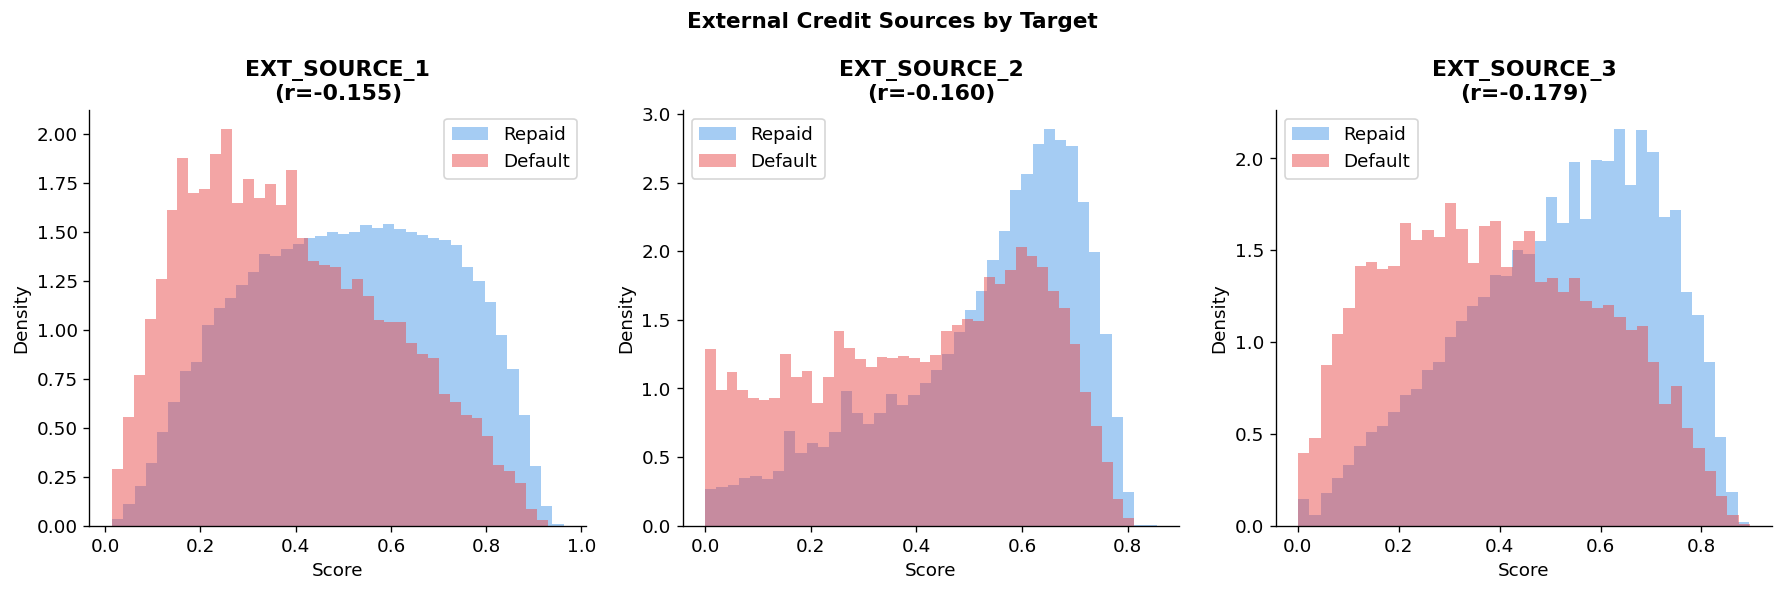

In [15]:
ext_cols = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]

print(f"\n  Coverage:")
for col in ext_cols:
    cov = df[col].notna().sum()
    print(f"    {col}: {cov:,} ({cov/len(df)*100:.1f}%) not missing")

print(f"\n  Correlation with TARGET:")
for col in ext_cols:
    corr = df[col].corr(df["TARGET"])
    print(f"    {col}: r = {corr:.4f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, col in enumerate(ext_cols):
    ax = axes[i]
    for tgt, color in PALETTE.items():
        data = df[df["TARGET"] == tgt][col].dropna()
        data.plot.hist(ax=ax, bins=40, color=color, alpha=0.5,
                       label=f"{'Repaid' if tgt==0 else 'Default'}", density=True)
    ax.set_title(f"{col}\n(r={df[col].corr(df['TARGET']):.3f})",
                 fontweight="bold")
    ax.set_xlabel("Score")
    ax.set_ylabel("Density")
    ax.legend()

plt.suptitle("External Credit Sources by Target", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


# EXT_SOURCE INTERACTIONS

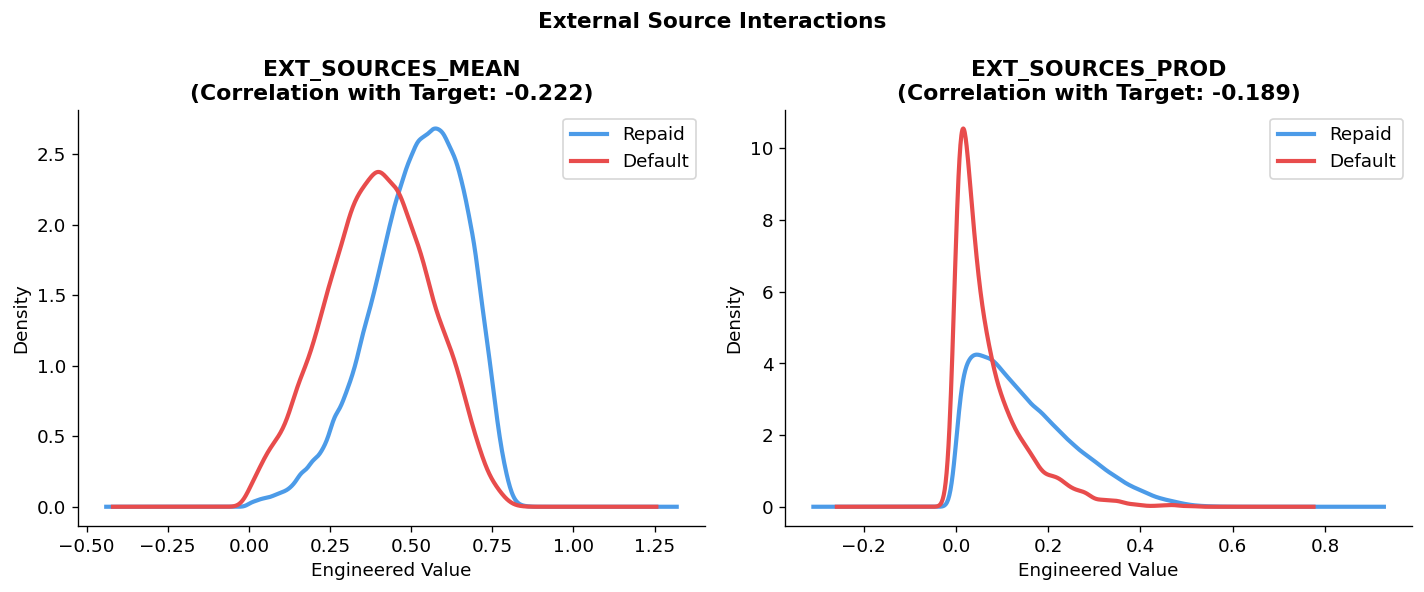

In [16]:
# Calculate the average and the product of the EXT_SOURCE values
df["EXT_SOURCES_MEAN"] = df[["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]].mean(axis=1)
df["EXT_SOURCES_PROD"] = df["EXT_SOURCE_1"] * df["EXT_SOURCE_2"] * df["EXT_SOURCE_3"]

interaction_cols = ["EXT_SOURCES_MEAN", "EXT_SOURCES_PROD"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, col in enumerate(interaction_cols):
    ax = axes[i]
    for tgt, color in PALETTE.items():
        data = df[df["TARGET"] == tgt][col].dropna()
        data.plot.kde(ax=ax, color=color, linewidth=2.5,
                      label=f"{'Repaid' if tgt==0 else 'Default'}")

    corr_val = df[col].corr(df['TARGET'])
    ax.set_title(f"{col}\n(Correlation with Target: {corr_val:.3f})", fontweight="bold")
    ax.set_xlabel("Engineered Value")
    ax.set_ylabel("Density")
    ax.legend()

plt.suptitle("External Source Interactions", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [17]:
df.drop(columns=interaction_cols, inplace=True, errors='ignore')

>  These interaction terms were created solely for visual
  validation of predictive power. They are removed here to give the
  Feature Engineering team a clean slate to perform their own
  transformations and prevent data leakage/redundancy.

In [18]:
anomaly_count = (df["DAYS_EMPLOYED"] == 365243).sum()
print(f"\n  Records with DAYS_EMPLOYED = 365,243 : {anomaly_count:,} ({anomaly_count/len(df)*100:.1f}%)")
print("  These correspond to 'XNA' ORGANIZATION_TYPE (unemployed/unknown).")
print("  → Action: replace with NaN or create a binary flag 'EMPLOYED_ANOMALY'.")

# Default rate comparison
rate_anomaly = df[df["DAYS_EMPLOYED"] == 365243]["TARGET"].mean()
rate_normal = df[df["DAYS_EMPLOYED"] != 365243]["TARGET"].mean()
print(f"\n  Default rate — anomaly group : {rate_anomaly:.4f}")
print(f"  Default rate — normal group  : {rate_normal:.4f}")


  Records with DAYS_EMPLOYED = 365,243 : 55,374 (18.0%)
  These correspond to 'XNA' ORGANIZATION_TYPE (unemployed/unknown).
  → Action: replace with NaN or create a binary flag 'EMPLOYED_ANOMALY'.

  Default rate — anomaly group : 0.0540
  Default rate — normal group  : 0.0866


#Financial Ratio Distributions


  Means by Target:
    Credit / Income                    : repaid=3.9637  default=3.8874
    Annuity / Income                   : repaid=0.1805  default=0.1855
    Debt / Income                      : repaid=3.5590  default=4.0294
    Bureau Debt / Credit               : repaid=0.2733  default=0.3746
    Previous Refusal Rate              : repaid=0.1066  default=0.1588
    Previous Approval Rate             : repaid=0.7538  default=0.6931
    Overall Late Payment Rate          : repaid=0.0328  default=0.0456


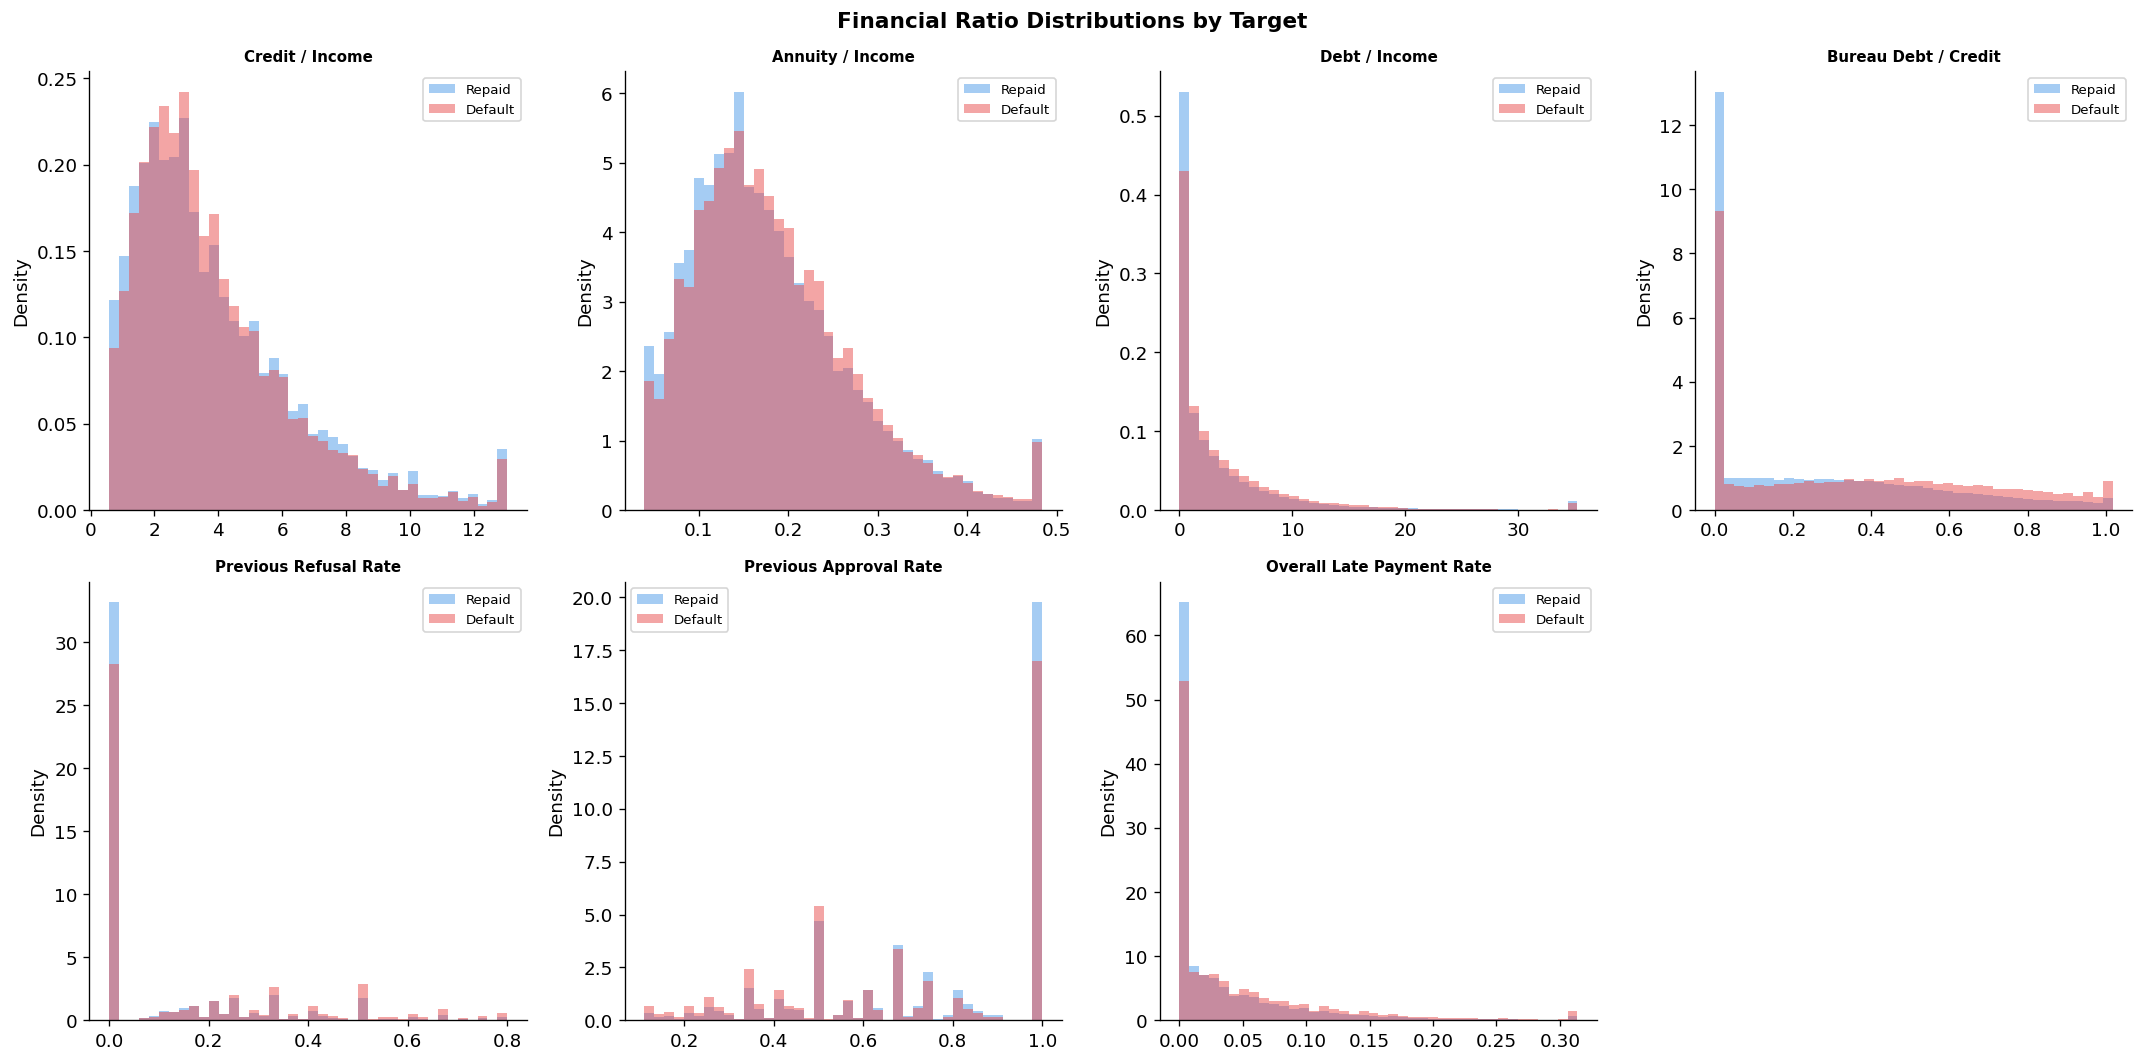

In [19]:
ratio_cols = {
    "credit_to_income": "Credit / Income",
    "annuity_to_income": "Annuity / Income",
    "debt_to_income": "Debt / Income",
    "bur_debt_to_credit_ratio": "Bureau Debt / Credit",
    "prev_refusal_rate": "Previous Refusal Rate",
    "prev_approval_rate": "Previous Approval Rate",
    "overall_late_payment_rate": "Overall Late Payment Rate",
}

print("\n  Means by Target:")
for col, label in ratio_cols.items():
    if col in df.columns:
        g = df.groupby("TARGET")[col].mean()
        print(f"    {label:35s}: repaid={g.get(0,np.nan):.4f}  default={g.get(1,np.nan):.4f}")

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, (col, label) in enumerate(ratio_cols.items()):
    if col not in df.columns or i >= len(axes):
        continue
    ax = axes[i]
    data0 = df[df["TARGET"] == 0][col].dropna()
    data1 = df[df["TARGET"] == 1][col].dropna()
    lo = min(data0.quantile(0.01), data1.quantile(0.01))
    hi = max(data0.quantile(0.99), data1.quantile(0.99))
    ax.hist(data0.clip(lo, hi), bins=40, color=PALETTE[0], alpha=0.5,
            density=True, label="Repaid")
    ax.hist(data1.clip(lo, hi), bins=40, color=PALETTE[1], alpha=0.5,
            density=True, label="Default")
    ax.set_title(label, fontsize=9, fontweight="bold")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

axes[-1].set_visible(False)
plt.suptitle("Financial Ratio Distributions by Target",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


#CORRELATION HEATMAP


  Top 30 features by correlation with TARGET:
     1. EXT_SOURCE_3                                  -0.1789
     2. EXT_SOURCE_2                                  -0.1605
     3. EXT_SOURCE_1                                  -0.1553
     4. bur_avg_days_credit                           +0.0897
     5. AGE_YEARS                                     -0.0782
     6. DAYS_BIRTH                                    +0.0782
     7. prev_refusal_rate                             +0.0777
     8. bur_active_ratio                              +0.0774
     9. cc_avg_utilization_3m                         +0.0767
    10. cc_avg_utilization_6m                         +0.0761
    11. YEARS_EMPLOYED                                -0.0750
    12. inst_late_payment_rate                        +0.0703
    13. inst_late_rate_1y                             +0.0688
    14. bur_active_count                              +0.0671
    15. prev_credit_to_app_ratio                      +0.0650
    16. cc_avg_utilizat

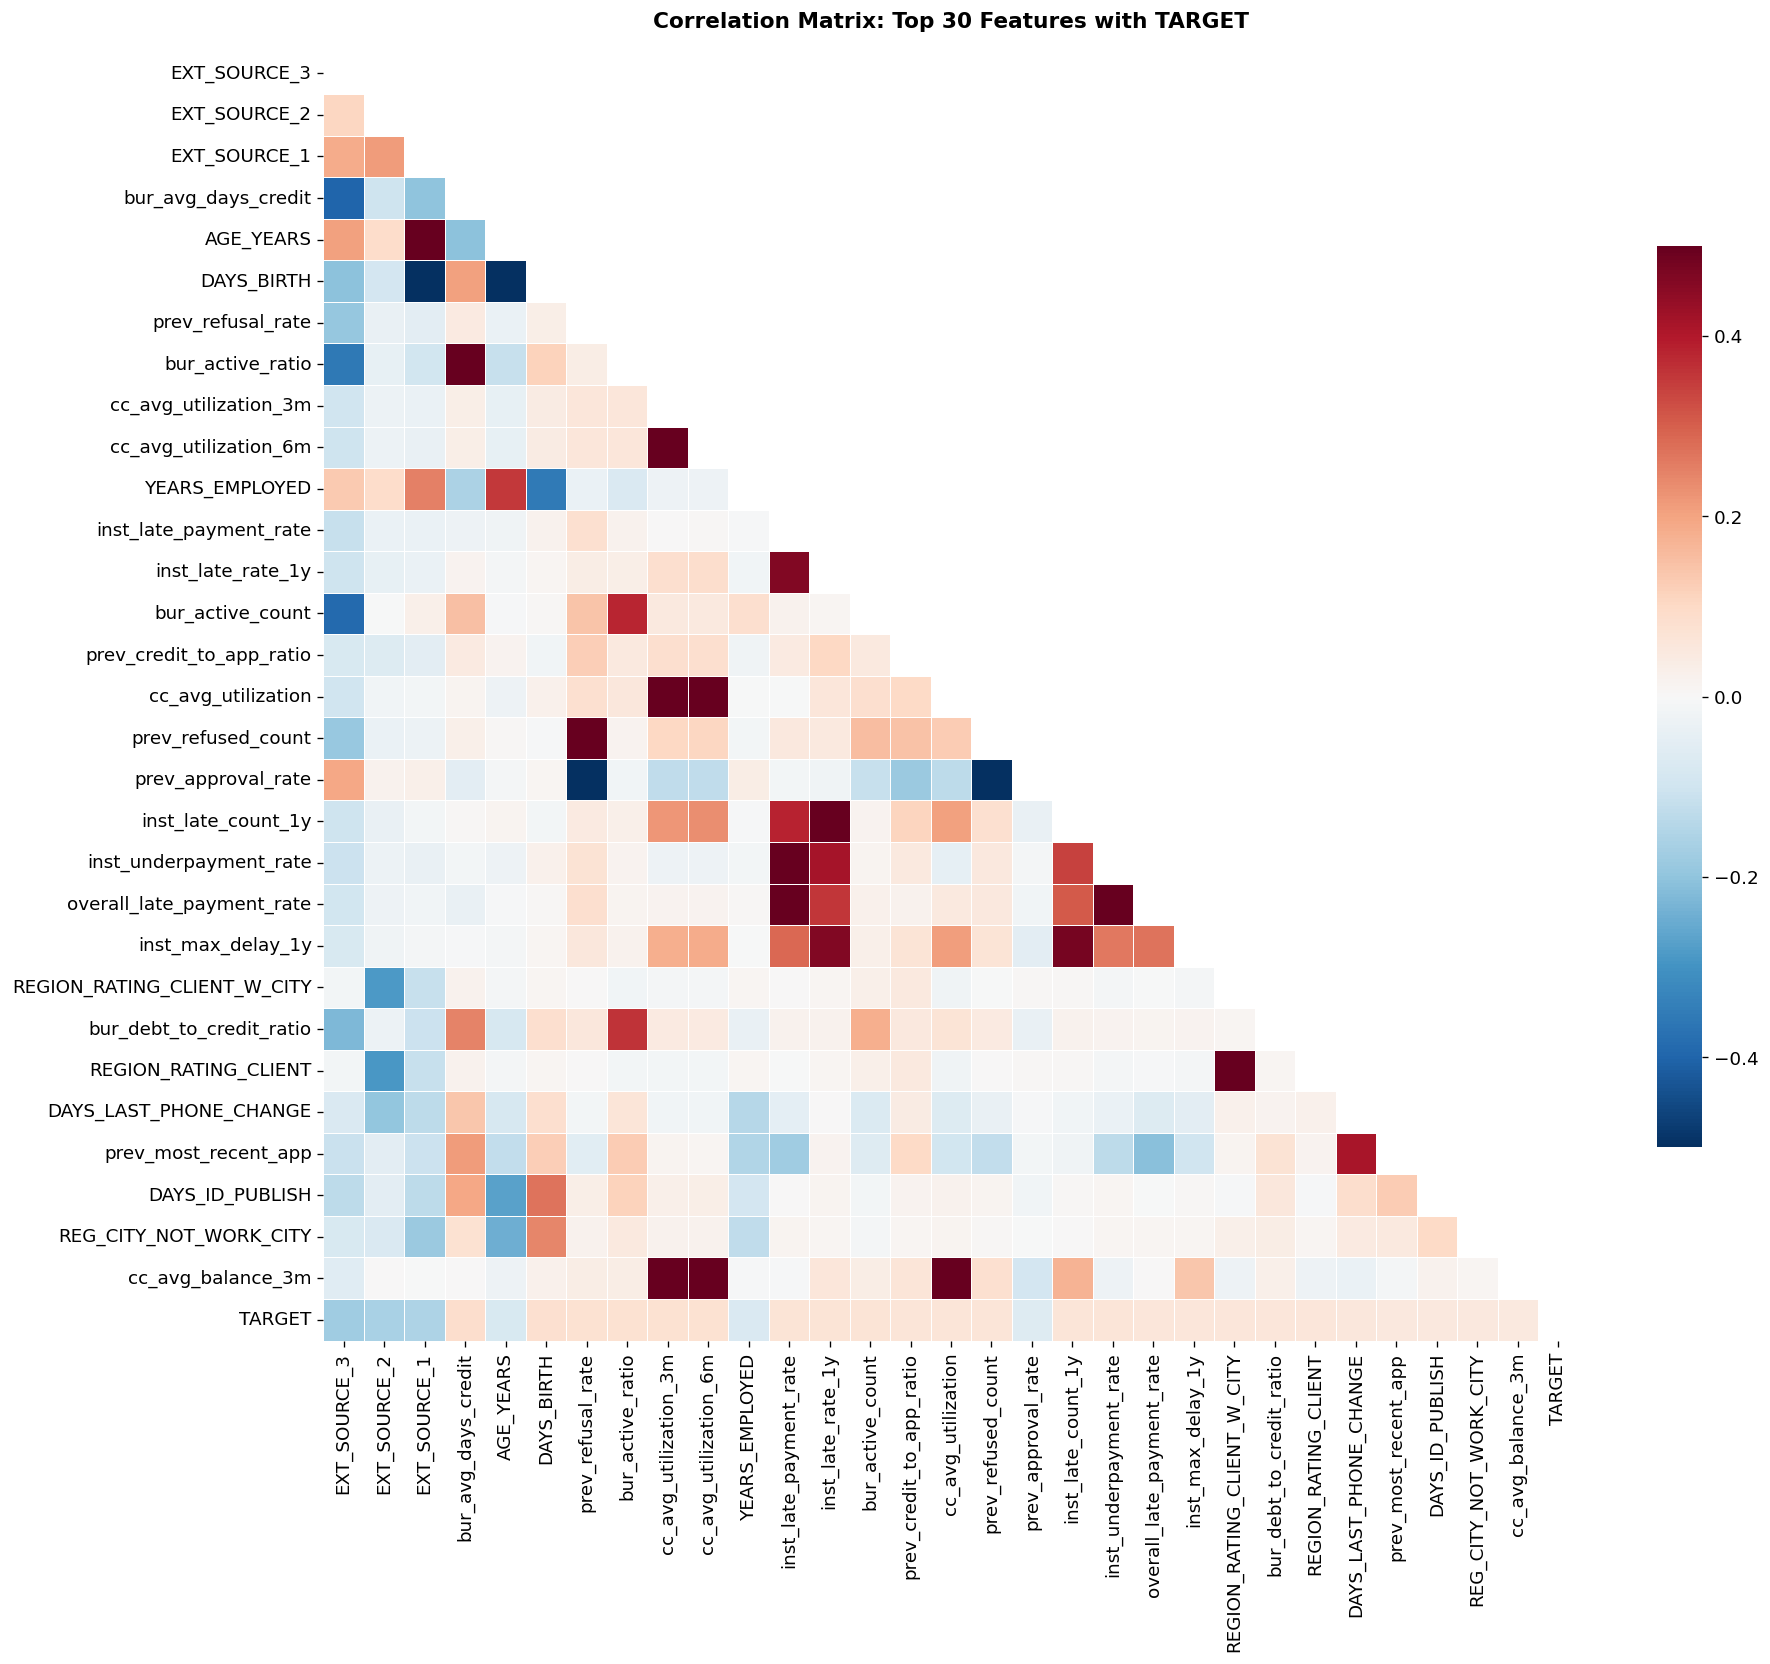

In [20]:
num_df = df.select_dtypes(include=[np.number])
target_corr = num_df.corr()["TARGET"].drop("TARGET").abs().sort_values(ascending=False)
top30 = target_corr.head(30).index.tolist()

print(f"\n  Top 30 features by correlation with TARGET:")
for rank, (feat, val) in enumerate(target_corr.head(30).items(), 1):
    direction = "+" if num_df[feat].corr(df["TARGET"]) > 0 else "-"
    print(f"    {rank:2d}. {feat:45s} {direction}{val:.4f}")

corr_matrix = num_df[top30 + ["TARGET"]].corr()

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap="RdBu_r", center=0,
            vmin=-0.5, vmax=0.5, linewidths=0.3,
            ax=ax, cbar_kws={"shrink": 0.7})
ax.set_title("Correlation Matrix: Top 30 Features with TARGET",
             fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.show()

#BUREAU / BEHAVIORAL FEATURES


  Default rate lift over mean for behavioral signals:

  [Bureau]
    bur_loan_count                          : Q1 dr=0.0820, Q4 dr=0.0807, lift=1.00x
    bur_active_count                        : Q1 dr=0.0654, Q4 dr=0.1072, lift=1.33x
    bur_avg_dpd_rate                        : Q1 dr=0.0773, Q4 dr=0.0773, lift=0.96x
    bur_debt_to_credit_ratio                : Q1 dr=0.0568, Q4 dr=0.1146, lift=1.42x
    bur_active_ratio                        : Q1 dr=0.0543, Q4 dr=0.1101, lift=1.36x

  [Previous App]
    prev_app_count                          : Q1 dr=0.0813, Q4 dr=0.0896, lift=1.11x
    prev_refusal_rate                       : Q1 dr=0.0716, Q4 dr=0.1163, lift=1.44x
    prev_approval_rate                      : Q1 dr=0.1108, Q4 dr=0.0702, lift=0.87x
    prev_avg_credit                         : Q1 dr=0.0908, Q4 dr=0.0761, lift=0.94x
    prev_credit_to_app_ratio                : Q1 dr=0.0620, Q4 dr=0.1126, lift=1.39x

  [POS Cash]
    pos_late_payment_rate                   : Q1 dr

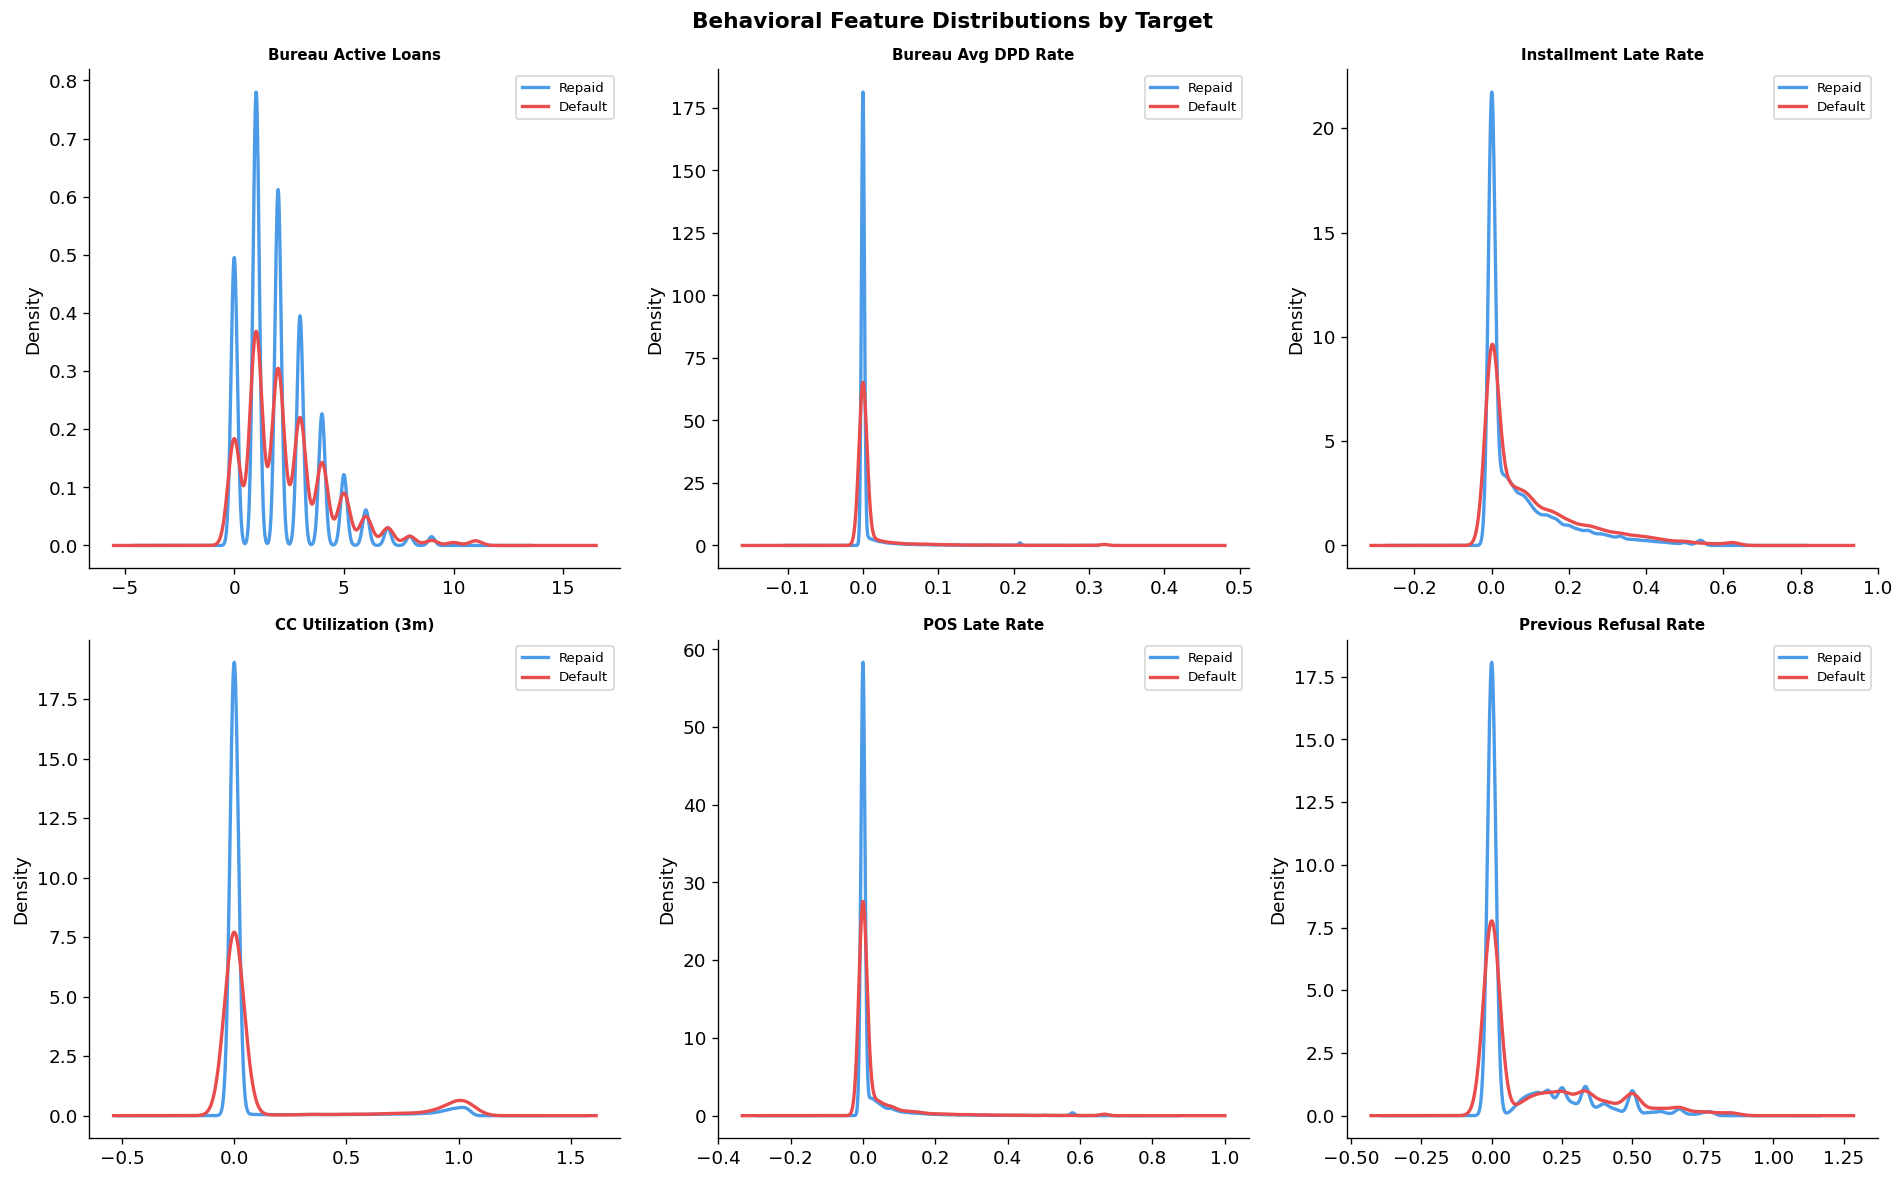

In [21]:
behavioral = {
    "Bureau": ["bur_loan_count", "bur_active_count", "bur_avg_dpd_rate",
               "bur_debt_to_credit_ratio", "bur_active_ratio"],
    "Previous App": ["prev_app_count", "prev_refusal_rate", "prev_approval_rate",
                     "prev_avg_credit", "prev_credit_to_app_ratio"],
    "POS Cash": ["pos_late_payment_rate", "pos_max_dpd", "pos_avg_dpd"],
    "Installments": ["inst_late_payment_rate", "inst_avg_payment_delay",
                     "inst_underpayment_rate"],
    "Credit Card": ["cc_avg_utilization", "cc_avg_utilization_3m",
                    "cc_avg_utilization_6m", "cc_missed_payment_rate"],
}

print("\n  Default rate lift over mean for behavioral signals:")
overall_dr = df["TARGET"].mean()
for group, cols in behavioral.items():
    print(f"\n  [{group}]")
    for col in cols:
        if col not in df.columns:
            continue
        # Bin into quartiles
        try:
            q_col = pd.qcut(df[col], 4, duplicates="drop")
            dr_by_q = df.groupby(q_col, observed=True)["TARGET"].mean()
            low_q = dr_by_q.iloc[0]
            high_q = dr_by_q.iloc[-1]
            lift = high_q / overall_dr if overall_dr > 0 else np.nan
            print(f"    {col:40s}: Q1 dr={low_q:.4f}, Q4 dr={high_q:.4f}, "
                  f"lift={lift:.2f}x")
        except Exception:
            pass

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

bureau_plot_cols = [
    ("bur_active_count", "Bureau Active Loans"),
    ("bur_avg_dpd_rate", "Bureau Avg DPD Rate"),
    ("inst_late_payment_rate", "Installment Late Rate"),
    ("cc_avg_utilization_3m", "CC Utilization (3m)"),
    ("pos_late_payment_rate", "POS Late Rate"),
    ("prev_refusal_rate", "Previous Refusal Rate"),
]

for i, (col, label) in enumerate(bureau_plot_cols):
    if col not in df.columns:
        axes[i].set_visible(False)
        continue
    ax = axes[i]
    for tgt, color in PALETTE.items():
        data = df[df["TARGET"] == tgt][col].dropna()
        lo, hi = data.quantile(0.005), data.quantile(0.995)
        data = data.clip(lo, hi)
        data.plot.kde(ax=ax, color=color, linewidth=2,
                      label=f"{'Repaid' if tgt==0 else 'Default'}")
    ax.set_title(label, fontsize=9, fontweight="bold")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.suptitle("Behavioral Feature Distributions by Target",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


  Age group analysis:
    (20, 30]: default rate = 0.1146
    (30, 40]: default rate = 0.0958
    (40, 50]: default rate = 0.0765
    (50, 60]: default rate = 0.0613
    (60, 70]: default rate = 0.0492

  Weekday application analysis:
WEEKDAY_APPR_PROCESS_START
TUESDAY      0.083505
WEDNESDAY    0.081604
FRIDAY       0.081469
THURSDAY     0.081003
SUNDAY       0.079291
SATURDAY     0.078873
MONDAY       0.077572

  Hour of application analysis:
    Peak default hour: 0 (0.1500)
    Lowest default hour: 21 (0.0617)


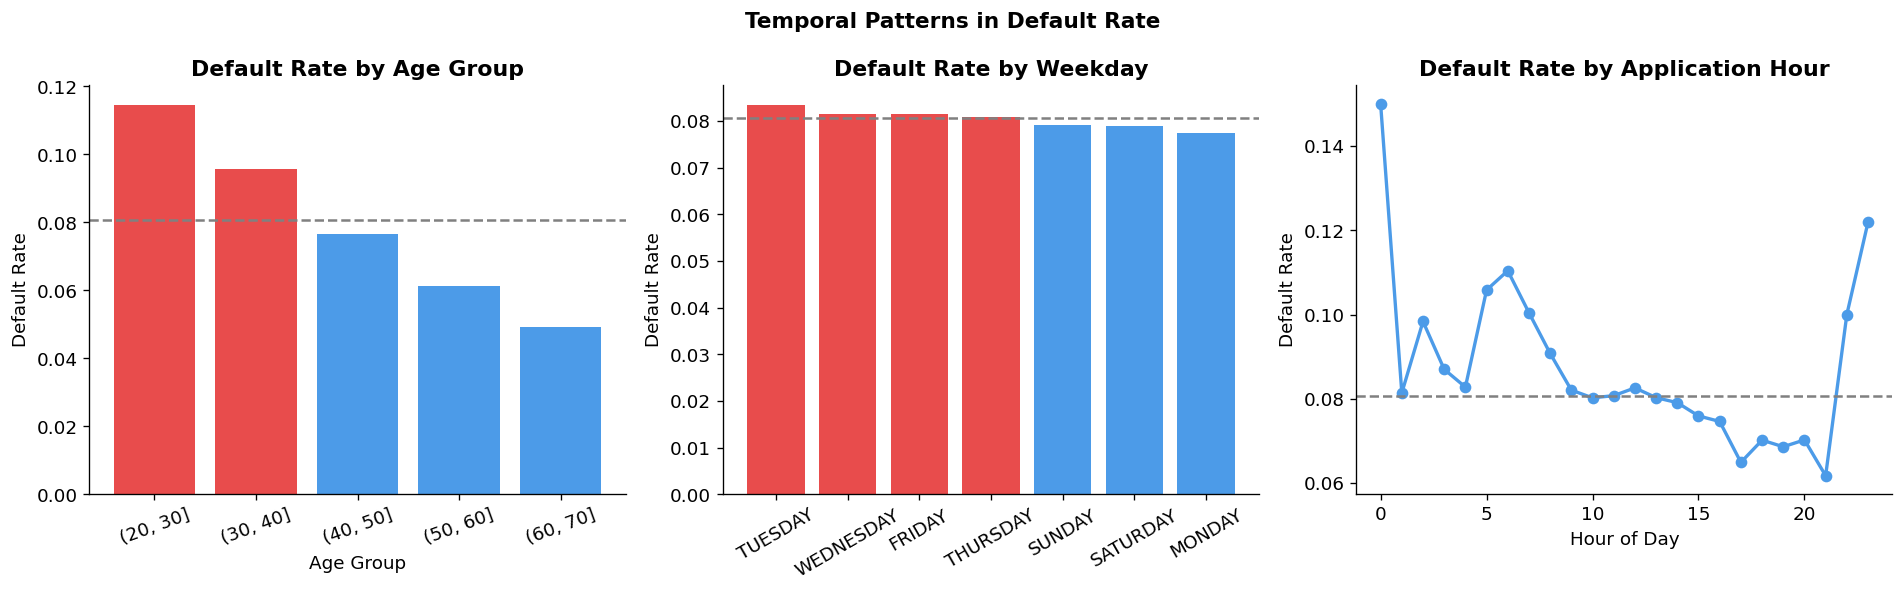

In [22]:
print("\n  Age group analysis:")
df["AGE_BIN"] = pd.cut(df["AGE_YEARS"], bins=[20, 30, 40, 50, 60, 70])
age_dr = df.groupby("AGE_BIN", observed=True)["TARGET"].mean()
for age, dr in age_dr.items():
    print(f"    {age}: default rate = {dr:.4f}")

print("\n  Weekday application analysis:")
weekday_dr = df.groupby("WEEKDAY_APPR_PROCESS_START")["TARGET"].mean().sort_values(ascending=False)
print(weekday_dr.to_string())

print("\n  Hour of application analysis:")
hour_dr = df.groupby("HOUR_APPR_PROCESS_START")["TARGET"].mean()
print(f"    Peak default hour: {hour_dr.idxmax()} ({hour_dr.max():.4f})")
print(f"    Lowest default hour: {hour_dr.idxmin()} ({hour_dr.min():.4f})")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Age vs default rate
axes[0].bar(age_dr.index.astype(str), age_dr.values,
            color=["#E84C4C" if v > overall_dr else "#4C9BE8" for v in age_dr.values])
axes[0].axhline(overall_dr, linestyle="--", color="gray")
axes[0].set_title("Default Rate by Age Group", fontweight="bold")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("Default Rate")
axes[0].tick_params(axis="x", rotation=20)

# Weekday
axes[1].bar(weekday_dr.index, weekday_dr.values,
            color=["#E84C4C" if v > overall_dr else "#4C9BE8" for v in weekday_dr.values])
axes[1].axhline(overall_dr, linestyle="--", color="gray")
axes[1].set_title("Default Rate by Weekday", fontweight="bold")
axes[1].set_ylabel("Default Rate")
axes[1].tick_params(axis="x", rotation=30)

# Hour
axes[2].plot(hour_dr.index, hour_dr.values, marker="o", color="#4C9BE8", linewidth=2)
axes[2].axhline(overall_dr, linestyle="--", color="gray")
axes[2].set_title("Default Rate by Application Hour", fontweight="bold")
axes[2].set_xlabel("Hour of Day")
axes[2].set_ylabel("Default Rate")

plt.suptitle("Temporal Patterns in Default Rate",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


#Outlier Summary

In [23]:
num_cols = df.select_dtypes(include=[np.number]).columns
outlier_report = []
for col in num_cols:
    series = df[col].dropna()
    if len(series) < 100:
        continue
    lo, hi = series.quantile(0.005), series.quantile(0.995)
    iqr = series.quantile(0.75) - series.quantile(0.25)
    if iqr == 0:
        continue
    outliers = ((series < lo) | (series > hi)).sum()
    outlier_report.append({
        "feature": col,
        "outlier_count": outliers,
        "outlier_pct": outliers / len(series) * 100,
        "min": series.min(),
        "max": series.max(),
        "IQR": iqr,
    })

outlier_df = pd.DataFrame(outlier_report).sort_values("outlier_pct", ascending=False)
print("\n  Top 20 features by outlier % (beyond 0.5th–99.5th percentile):")
print(outlier_df.head(20).to_string(index=False))


  Top 20 features by outlier % (beyond 0.5th–99.5th percentile):
               feature  outlier_count  outlier_pct           min           max          IQR
          EXT_SOURCE_1           1342     1.000500  1.456813e-02  9.626928e-01 3.410453e-01
prev_credit_to_current           2912     1.000491  0.000000e+00  1.972336e+01 3.724627e-01
       prev_avg_credit           2912     1.000491  0.000000e+00  4.050000e+06 1.492226e+05
 inst_avg_payment_diff           2912     1.000491 -1.461459e+05  3.374968e+05 4.465747e+02
inst_avg_payment_delay           2912     1.000491 -2.950000e+02  1.884205e+03 8.979487e+00
          EXT_SOURCE_2           3070     1.000486  8.173617e-08  8.549997e-01 2.711596e-01
        bur_avg_credit           2636     1.000417  0.000000e+00  1.980724e+08 2.906162e+05
            SK_ID_CURR           3076     1.000289  1.000020e+05  4.562550e+05 1.779970e+05
     annuity_to_income           3075     1.000003  2.238846e-04  1.875965e+00 1.142849e-01
     inst_avg_

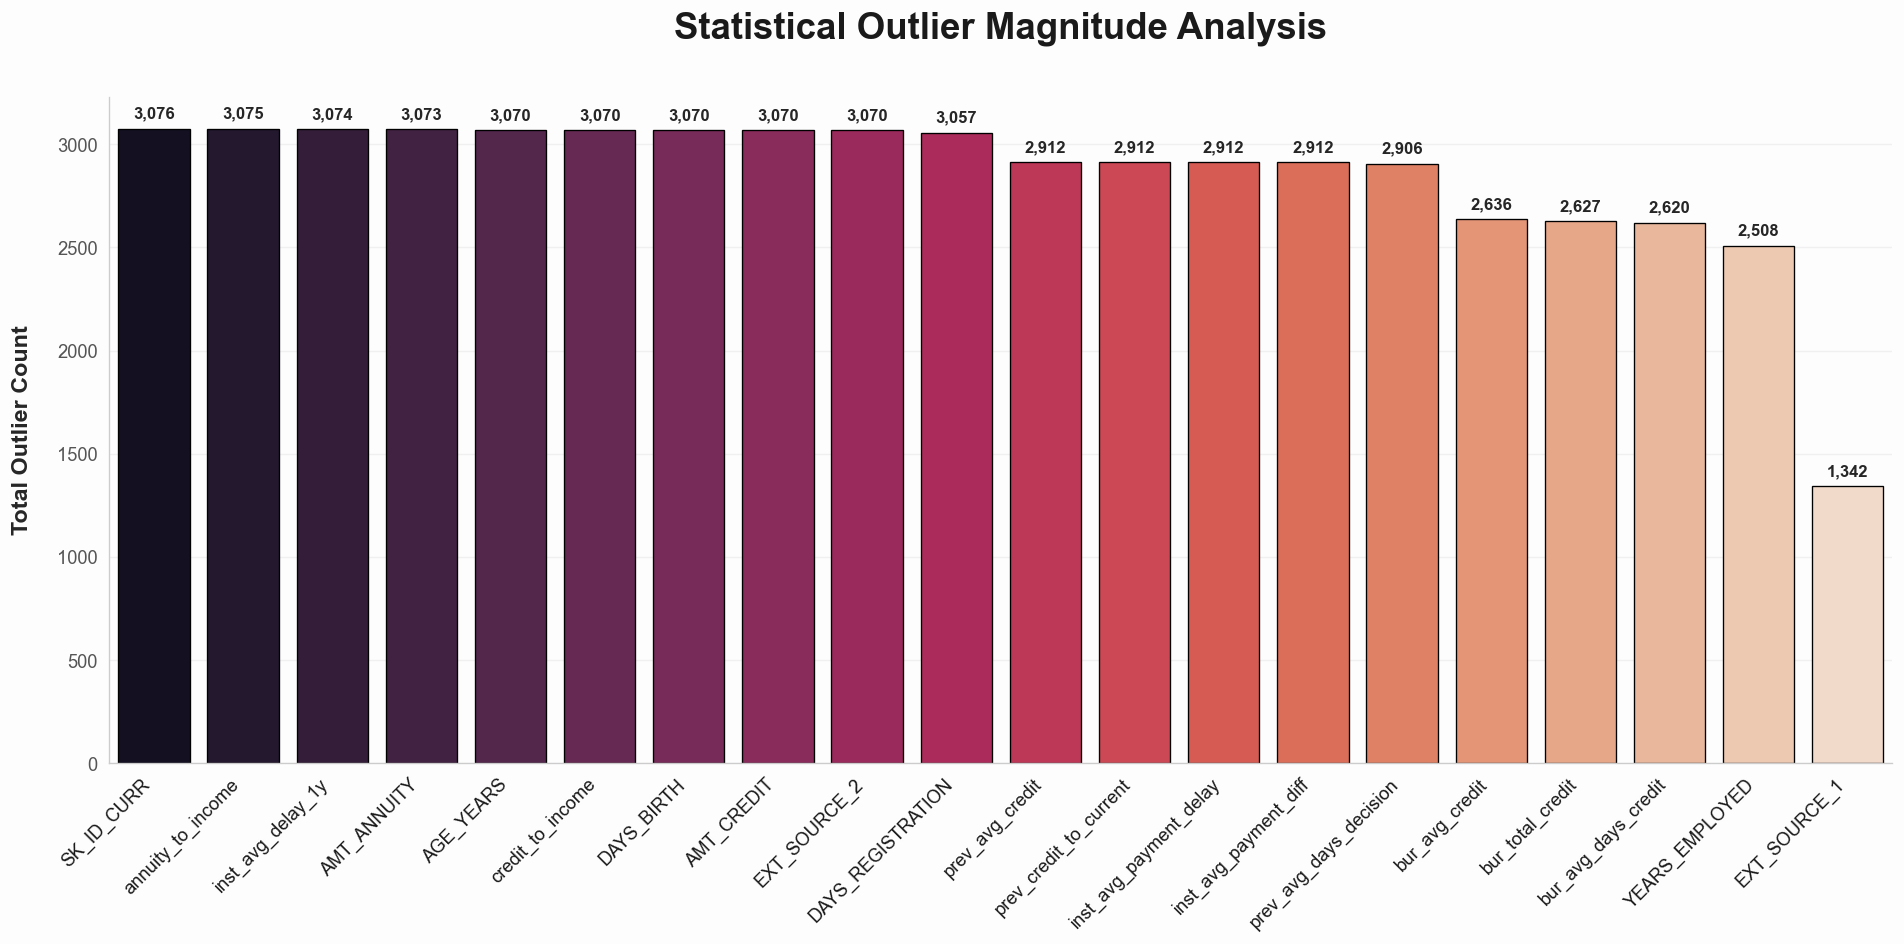

In [24]:
plt.figure(figsize=(16, 8), facecolor='#fdfdfd')
sns.set_style("whitegrid", {"axes.facecolor": "#fdfdfd", "grid.color": "#f0f0f0"})

ax = sns.barplot(
    x='feature',
    y='outlier_count',
    data=outlier_df.head(20).sort_values('outlier_count', ascending=False),
    palette='rocket',
    edgecolor="black",
    linewidth=0.8
)

plt.title('Statistical Outlier Magnitude Analysis', fontsize=22, fontweight='bold', pad=35, color='#1a1a1a')

plt.ylabel('Total Outlier Count', fontsize=14, fontweight='semibold', labelpad=15)
plt.xlabel('')

plt.xticks(rotation=45, ha='right', fontsize=11, color='#1a1a1a')
plt.yticks(fontsize=11, color='#555555')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 9),
                textcoords = 'offset points',
                fontsize=10, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

# FEATURE IMPORTANCE (CORRELATION-BASED)


  Group-level predictive power (avg |correlation| with TARGET):
    External Scores               : mean |r| = 0.1649
    Demographic                   : mean |r| = 0.0782
    Financial Ratios              : mean |r| = 0.0125
    Bureau History                : mean |r| = 0.0757
    Prev Application              : mean |r| = 0.0687
    Installment Behavior          : mean |r| = 0.0668
    Credit Card Behavior          : mean |r| = 0.0725
    Regional                      : mean |r| = 0.0559


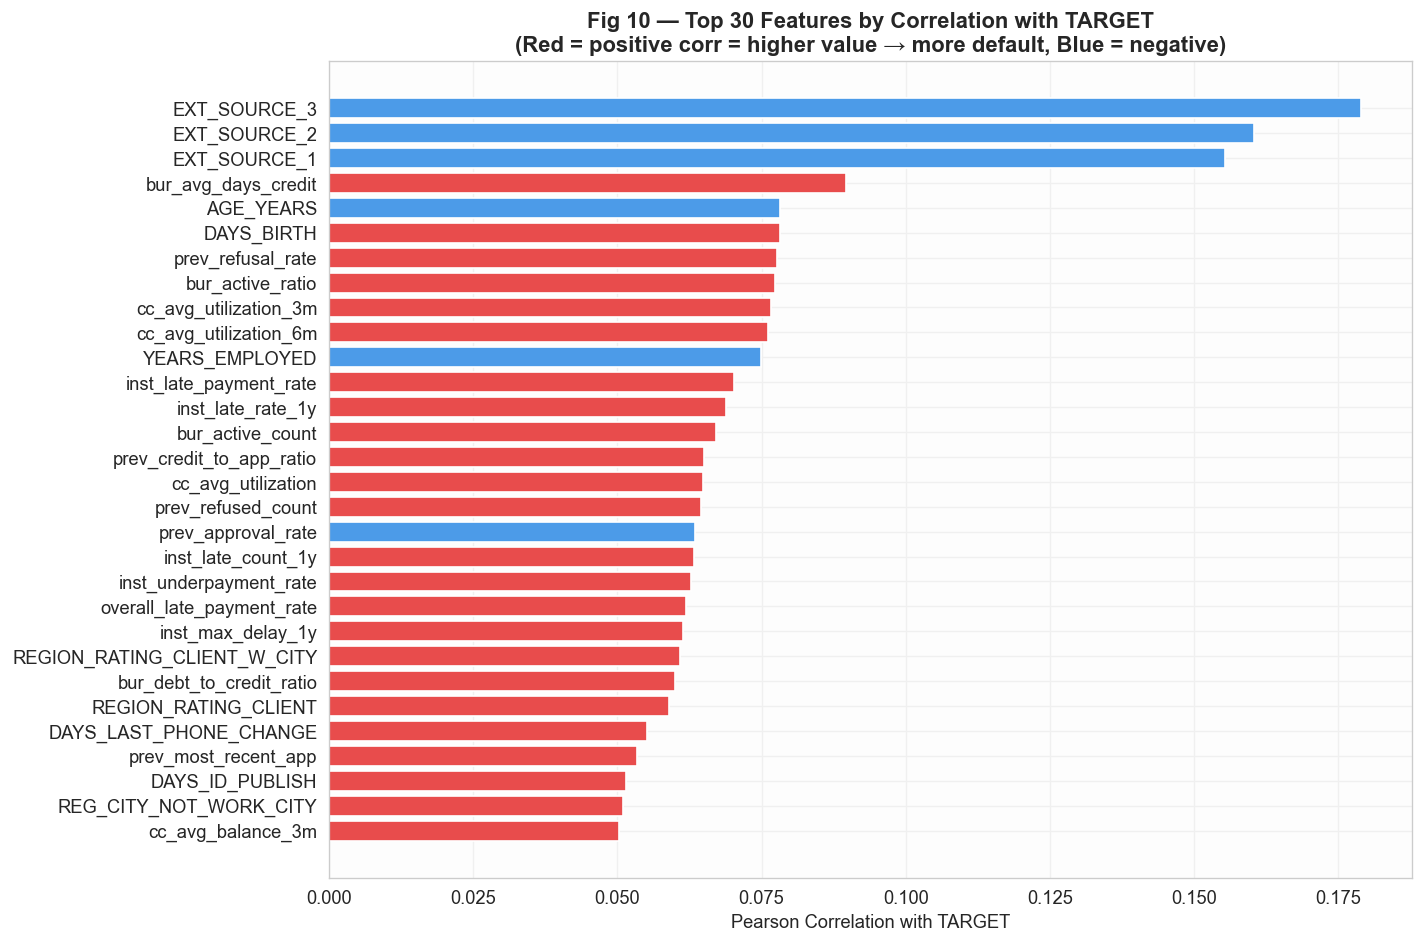

In [25]:
feature_groups = {
    "External Scores": ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"],
    "Demographic": ["DAYS_BIRTH", "CODE_GENDER", "NAME_EDUCATION_TYPE"],
    "Financial Ratios": ["credit_to_income", "annuity_to_income", "debt_to_income"],
    "Bureau History": ["bur_active_ratio", "bur_avg_days_credit",
                       "bur_debt_to_credit_ratio"],
    "Prev Application": ["prev_refusal_rate", "prev_credit_to_app_ratio",
                         "prev_approval_rate"],
    "Installment Behavior": ["inst_late_payment_rate", "inst_late_rate_1y",
                              "inst_max_delay_1y"],
    "Credit Card Behavior": ["cc_avg_utilization", "cc_avg_utilization_3m",
                              "cc_avg_utilization_6m"],
    "Regional": ["REGION_RATING_CLIENT_W_CITY", "REG_CITY_NOT_WORK_CITY"],
}

print("\n  Group-level predictive power (avg |correlation| with TARGET):")
for group, cols in feature_groups.items():
    avail = [c for c in cols if c in num_df.columns]
    if not avail:
        continue
    avg_corr = num_df[avail].corrwith(df["TARGET"]).abs().mean()
    print(f"    {group:30s}: mean |r| = {avg_corr:.4f}")

fig, ax = plt.subplots(figsize=(12, 8))
top50_corr = target_corr.head(30)
colors = ["#E84C4C" if num_df[c].corr(df["TARGET"]) > 0
          else "#4C9BE8" for c in top50_corr.index]
ax.barh(top50_corr.index[::-1], top50_corr.values[::-1], color=colors[::-1])
ax.set_xlabel("Pearson Correlation with TARGET")
ax.set_title("Fig 10 — Top 30 Features by Correlation with TARGET\n"
             "(Red = positive corr = higher value → more default, "
             "Blue = negative)", fontweight="bold")
plt.tight_layout()
plt.show()



#ADVANCED FEATURE IMPORTANCE (**LightGBM**)

  Training LightGBM on 214 features to identify key risk drivers.


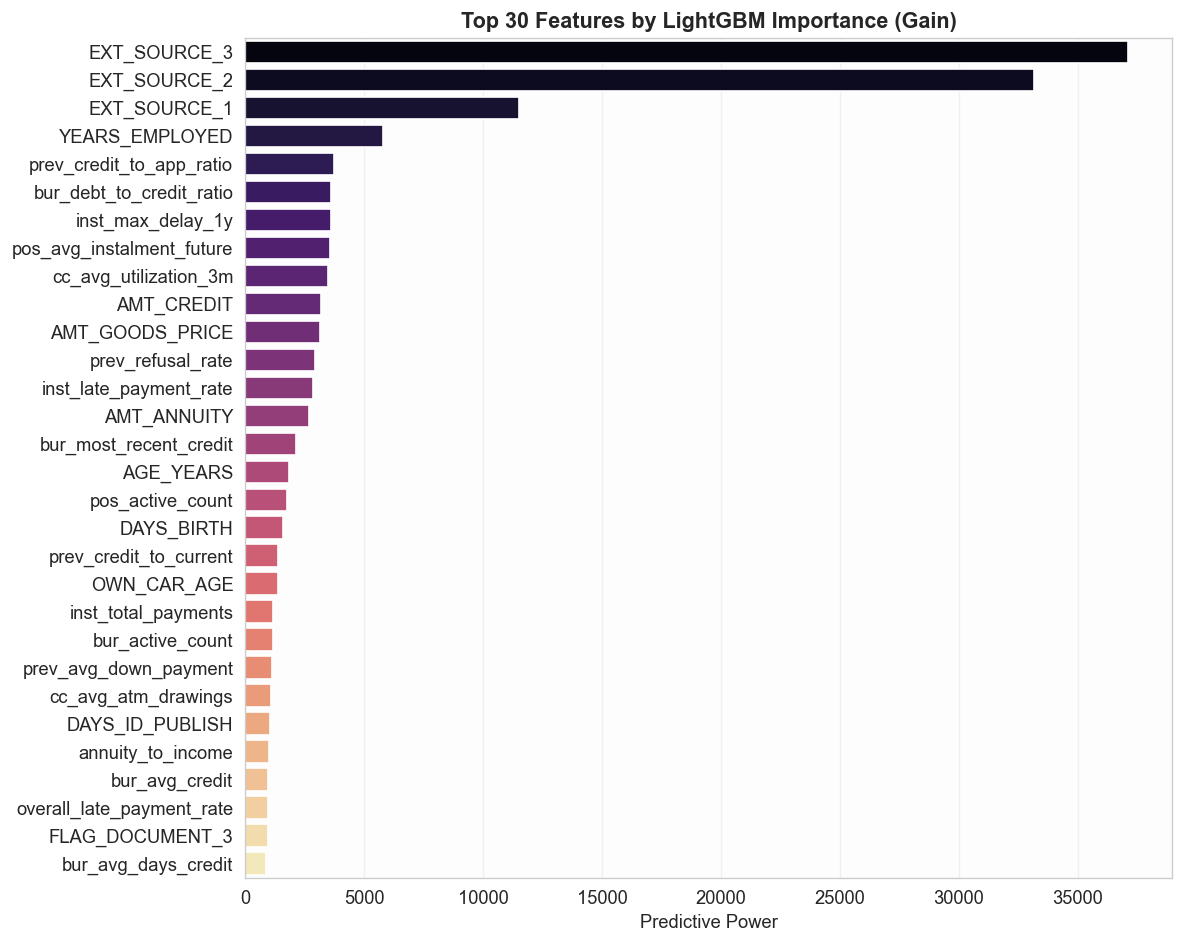

In [26]:
import lightgbm as lgb

X_numeric = df.select_dtypes(include=[np.number])

# Define columns to drop from the numeric feature set.
cols_to_drop_from_X = ["TARGET", "SK_ID_CURR"]

X = X_numeric.drop(columns=[c for c in cols_to_drop_from_X if c in X_numeric.columns])
y = df["TARGET"]

print(f"  Training LightGBM on {X.shape[1]} features to identify key risk drivers.")

lgbm_model = lgb.LGBMClassifier(
    n_estimators=100,
    importance_type='gain', #total information gain in the branches
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgbm_model.fit(X, y)

importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': lgbm_model.feature_importances_
}).sort_values('importance', ascending=False)

# FEATURE IMPORTANCE BAR CHART
fig, ax = plt.subplots(figsize=(10, 8))
top_30_features = importance_df.head(30)

sns.barplot(data=top_30_features, x='importance', y='feature', palette="magma", ax=ax)
ax.set_title("Top 30 Features by LightGBM Importance (Gain)", fontsize=13, fontweight="bold")
ax.set_xlabel("Predictive Power")
ax.set_ylabel("")

plt.tight_layout()
plt.show()

* Dominance of External Scores: "The EXT_SOURCE variables (1, 2, and 3) emerge as the most powerful predictors. This indicates that third-party credit ratings provide the strongest initial filter for assessing default probability."

* Significance of Financial Ratios: "Engineered features such as annuity_to_income and credit_to_income rank significantly higher than raw income figures, suggesting that a customer’s repayment capacity is more critical than their total wealth."

* Behavioral Continuity: "Metrics from previous applications (e.g., prev_refusal_rate) and bureau history show that past financial discipline is a persistent indicator of future performance."

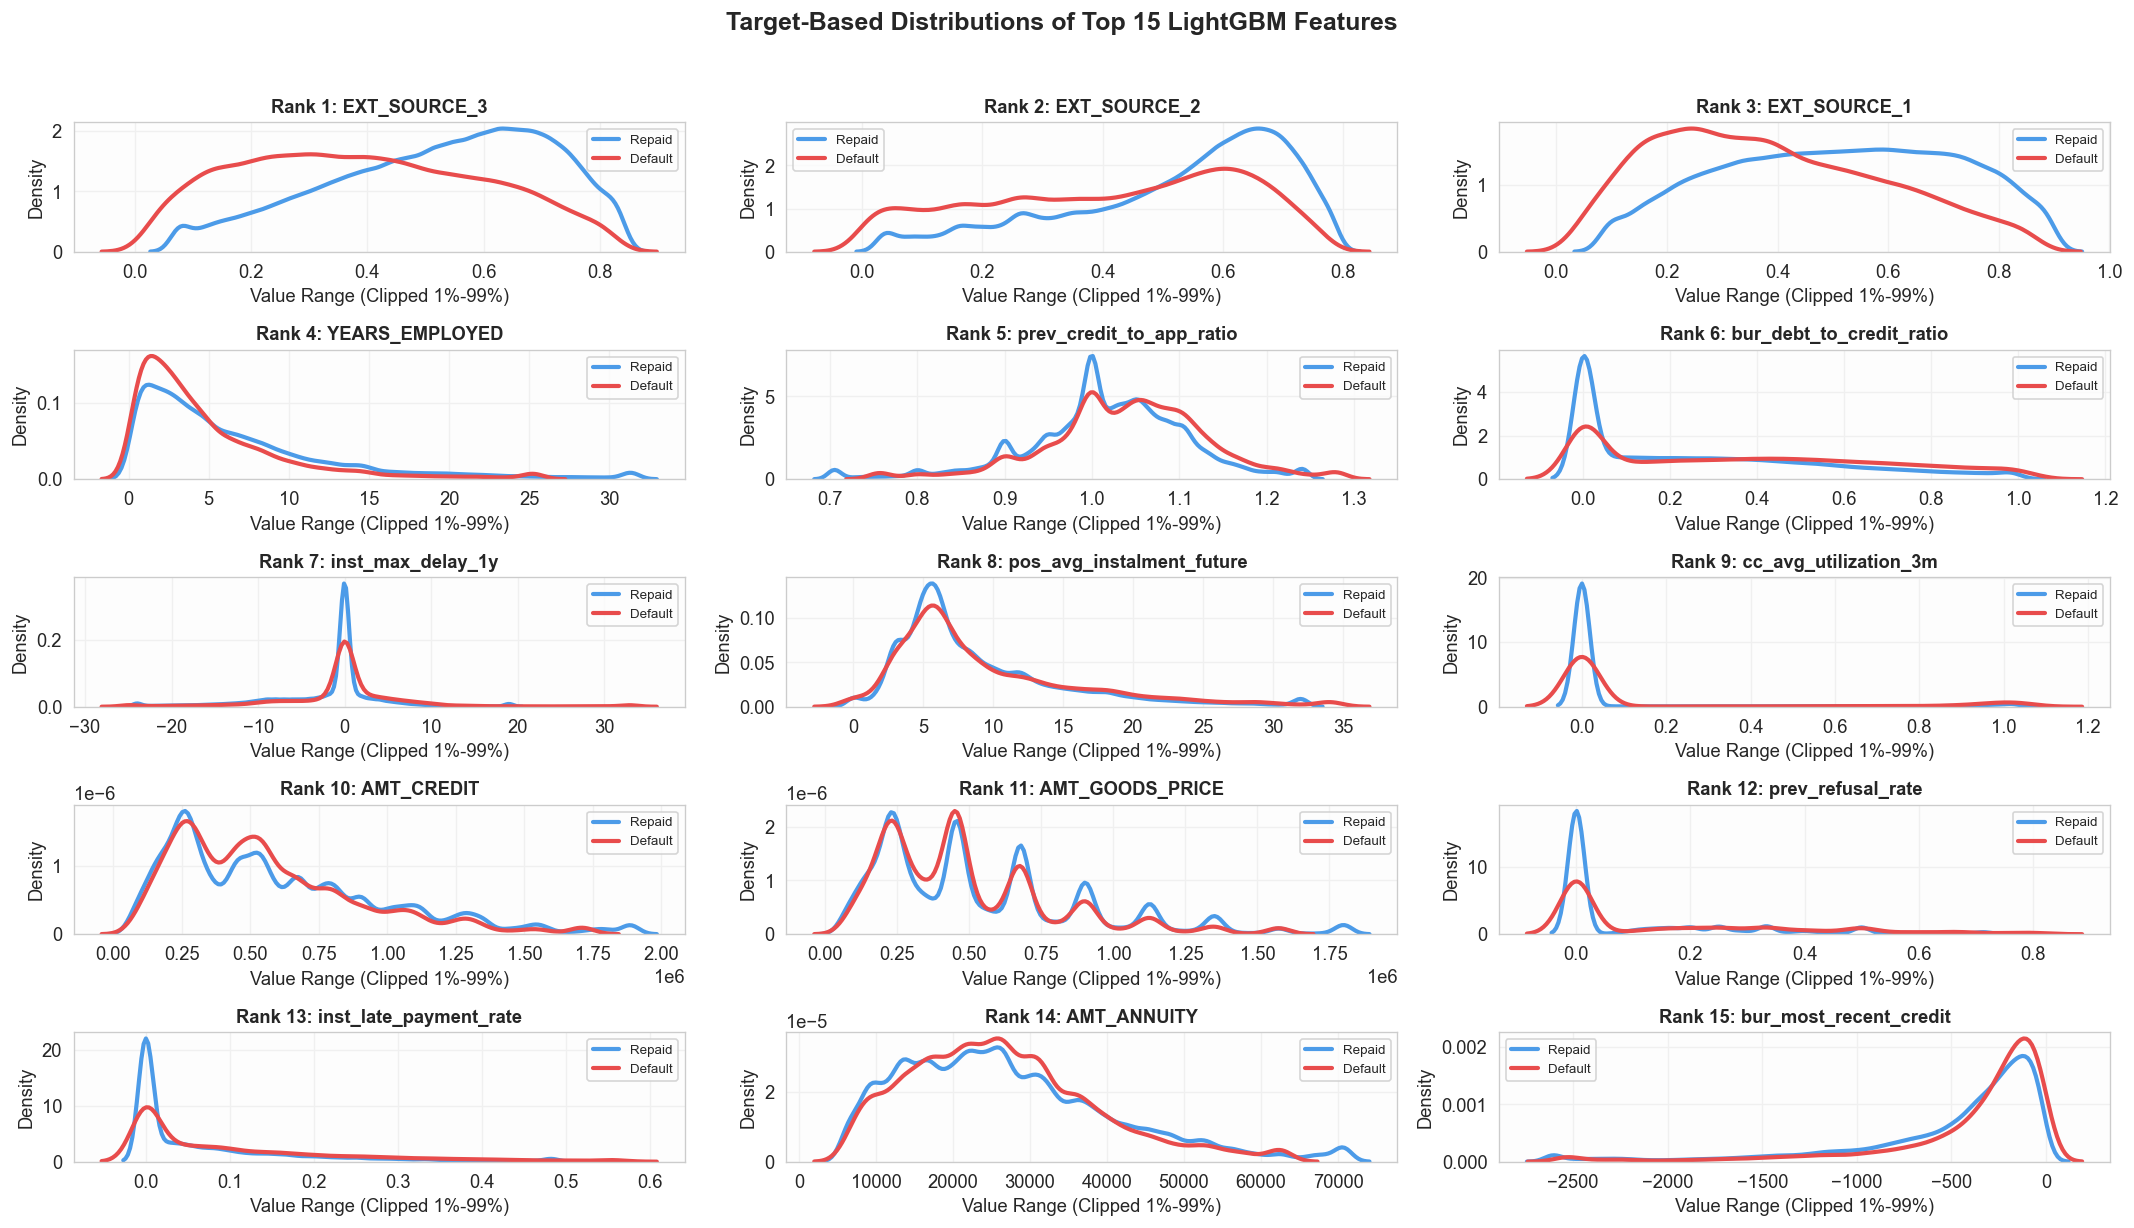

In [27]:
top_15_list = importance_df.head(15)['feature'].tolist()

fig, axes = plt.subplots(5, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(top_15_list):
    ax = axes[i]
    for tgt, color in PALETTE.items():
        # Let’s remove the outliers to get a clearer picture (between the 1st and 99th percentiles)
        data = df[df["TARGET"] == tgt][col].dropna()
        if not data.empty:
            lower, upper = data.quantile(0.01), data.quantile(0.99)
            sns.kdeplot(data.clip(lower, upper), ax=ax, color=color,
                        label=f"{'Repaid' if tgt==0 else 'Default'}", linewidth=2.5)

    ax.set_title(f"Rank {i+1}: {col}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Value Range (Clipped 1%-99%)")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.suptitle("Target-Based Distributions of Top 15 LightGBM Features",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

>*Diverging Plots*: If the peaks for “Default” (Red) and “Repaid” (Blue) are far apart or have very different shapes (such as one being tilted to the right and the other to the left), that variable is a strong discriminator.

>*Overlapping Plots:* If the two colors are almost on the same line, the variable’s standalone power is weak, but the model may have identified it as significant due to its interaction with other variables.

### External Sources (**EXT_SOURCE_1/2/3**)
* The distributions for 'Repaid' (Blue) and 'Default' (Red) show a clear separation. Repaid loans are heavily skewed toward higher scores, while defaults are concentrated in the lower score ranges.

**Insight**: These features act as primary discriminators. A score below a certain threshold (e.g., 0.3) exponentially increases the risk profile.

### Age & Employment Duration (DAYS_BIRTH / DAYS_EMPLOYED)
* The 'Default' density is notably higher among younger applicants (lower DAYS_BIRTH absolute values). Similarly, shorter employment tenures correlate with higher default rates.

Insight: Financial stability appears to be a function of time. Younger customers or those with frequent job changes lack the 'buffer' to withstand financial shocks.

### Payment Behavior (inst_late_payment_rate / bur_active_count)
* The distribution of late payment rates is heavily right-skewed for defaulted clients. Even a small increase in the late payment ratio significantly shifts the probability toward default.

**Insight**: Behavioral 'red flags' in installment history are the most immediate warning signs. Customers who struggle with small, frequent payments are highly likely to fail on larger credit obligations.
### Credit and Annuity Amounts
* There is a noticeable 'risk hump' in the mid-to-high credit ranges. While high-income individuals take larger loans, the default rate peaks when the annuity (monthly payment) consumes a larger portion of the disposable income.

**Insight**: The risk is not in the loan size itself, but in the debt-to-income burden.

#### INCLUDING CATEGORICAL COLUMNS WITH IMPUTING

In [30]:
cat_cols = ["NAME_CONTRACT_TYPE", "CODE_GENDER", "FLAG_OWN_CAR",
            "FLAG_OWN_REALTY", "NAME_TYPE_SUITE", "NAME_INCOME_TYPE", 
            "NAME_EDUCATION_TYPE", "NAME_FAMILY_STATUS", "NAME_HOUSING_TYPE", 
            "OCCUPATION_TYPE", "WEEKDAY_APPR_PROCESS_START", "ORGANIZATION_TYPE",
            "FONDKAPREMONT_MODE", "HOUSETYPE_MODE", "WALLSMATERIAL_MODE", 
            "EMERGENCYSTATE_MODE"]

from category_encoders import TargetEncoder
# Fill nulls and encode
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

# Target encode — replaces each category with its mean TARGET value
te = TargetEncoder(cols=cat_cols, smoothing=1.0)
df[cat_cols] = te.fit_transform(df[cat_cols], df['TARGET'])

print(f"Target encoded {len(cat_cols)} categorical columns")
print(df[cat_cols].head())

Target encoded 16 categorical columns
   NAME_CONTRACT_TYPE  CODE_GENDER  ...  WALLSMATERIAL_MODE  EMERGENCYSTATE_MODE
0            0.083459     0.101419  ...            0.074057             0.069649
1            0.083459     0.069993  ...            0.070247             0.069649
2            0.054783     0.101419  ...            0.091281             0.092607
3            0.083459     0.069993  ...            0.091281             0.092607
4            0.083459     0.101419  ...            0.091281             0.092607

[5 rows x 16 columns]


#  BORUTA FEATURE SELECTION (ALTERNATIVE)

Iteration: 	1 / 200
Confirmed: 	0
Tentative: 	230
Rejected: 	0
Iteration: 	2 / 200
Confirmed: 	0
Tentative: 	230
Rejected: 	0
Iteration: 	3 / 200
Confirmed: 	0
Tentative: 	230
Rejected: 	0
Iteration: 	4 / 200
Confirmed: 	0
Tentative: 	230
Rejected: 	0
Iteration: 	5 / 200
Confirmed: 	0
Tentative: 	230
Rejected: 	0
Iteration: 	6 / 200
Confirmed: 	0
Tentative: 	230
Rejected: 	0
Iteration: 	7 / 200
Confirmed: 	0
Tentative: 	230
Rejected: 	0
Iteration: 	8 / 200
Confirmed: 	127
Tentative: 	45
Rejected: 	58
Iteration: 	9 / 200
Confirmed: 	127
Tentative: 	45
Rejected: 	58
Iteration: 	10 / 200
Confirmed: 	127
Tentative: 	45
Rejected: 	58
Iteration: 	11 / 200
Confirmed: 	127
Tentative: 	45
Rejected: 	58
Iteration: 	12 / 200
Confirmed: 	134
Tentative: 	38
Rejected: 	58
Iteration: 	13 / 200
Confirmed: 	134
Tentative: 	38
Rejected: 	58
Iteration: 	14 / 200
Confirmed: 	134
Tentative: 	38
Rejected: 	58
Iteration: 	15 / 200
Confirmed: 	134
Tentative: 	38
Rejected: 	58
Iteration: 	16 / 200
Confirmed: 	

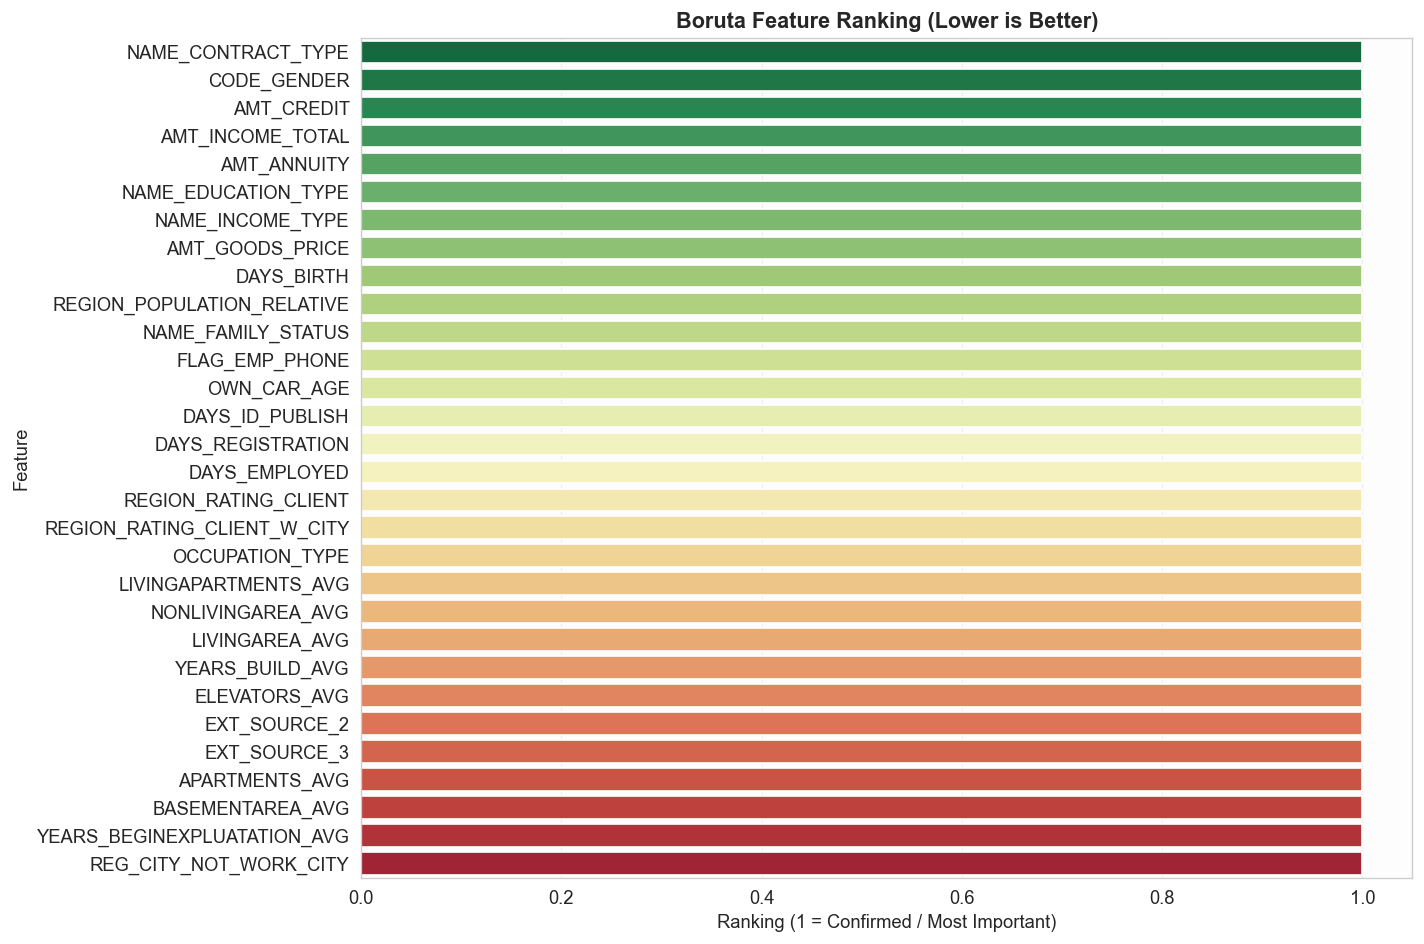

In [32]:
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier

#boruta is computationally expensive; 10k rows used for efficiency.
#fillna(-999): Scikit-learn's Random Forest does not support NaNs.
#we use -999 as an 'Arbitrary Value Imputation' to act as a 'Missing Flag'.
#since trees are invariant to scale, this keeps the 'missingness' as a
#distinguishable feature without biasing the mean or median.
boruta_df = df.select_dtypes(include=[np.number]).sample(n=150000, random_state=42)
X_boruta = boruta_df.drop(columns=["TARGET", "SK_ID_CURR"], errors='ignore').fillna(-999)
y_boruta = boruta_df["TARGET"]

# base estimator random forest
rf = RandomForestClassifier(n_jobs=-1, class_weight='balanced', max_depth=5, min_samples_leaf = 5) 

# 3. boruta
feat_selector = BorutaPy(rf, n_estimators='auto', verbose=2, random_state=42, max_iter=200)

feat_selector.fit(X_boruta.values, y_boruta.values)

boruta_res = pd.DataFrame({
    'Feature': X_boruta.columns,
    'Status': feat_selector.support_,
    'Tentative': feat_selector.support_weak_,
    'Ranking': feat_selector.ranking_
}).sort_values(by='Ranking')

confirmed = boruta_res[boruta_res['Status'] == True]
print(f" Confirmed Features: {len(confirmed)}")
print(f" Top 10 Confirmed:\n{confirmed.head(10)['Feature'].to_list()}")

fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(data=boruta_res.head(30), x='Ranking', y='Feature', palette="RdYlGn_r", ax=ax)
ax.set_title("Boruta Feature Ranking (Lower is Better)", fontsize=13, fontweight="bold")
ax.set_xlabel("Ranking (1 = Confirmed / Most Important)")
plt.tight_layout()
plt.show()

In [33]:
#confirmed_features
confirmed_features = boruta_res[boruta_res['Status'] == True]['Feature'].tolist()

print(f"Top {len(confirmed_features)} Confirmed Features by Boruta:\n")
for i, feature in enumerate(confirmed_features, 1):
    print(f"{i:2d}. {feature}")

Top 150 Confirmed Features by Boruta:

 1. NAME_CONTRACT_TYPE
 2. CODE_GENDER
 3. AMT_CREDIT
 4. AMT_INCOME_TOTAL
 5. AMT_ANNUITY
 6. NAME_EDUCATION_TYPE
 7. NAME_INCOME_TYPE
 8. AMT_GOODS_PRICE
 9. DAYS_BIRTH
10. REGION_POPULATION_RELATIVE
11. NAME_FAMILY_STATUS
12. FLAG_EMP_PHONE
13. OWN_CAR_AGE
14. DAYS_ID_PUBLISH
15. DAYS_REGISTRATION
16. DAYS_EMPLOYED
17. REGION_RATING_CLIENT
18. REGION_RATING_CLIENT_W_CITY
19. OCCUPATION_TYPE
20. LIVINGAPARTMENTS_AVG
21. NONLIVINGAREA_AVG
22. LIVINGAREA_AVG
23. YEARS_BUILD_AVG
24. ELEVATORS_AVG
25. EXT_SOURCE_2
26. EXT_SOURCE_3
27. APARTMENTS_AVG
28. BASEMENTAREA_AVG
29. YEARS_BEGINEXPLUATATION_AVG
30. REG_CITY_NOT_WORK_CITY
31. EXT_SOURCE_1
32. ORGANIZATION_TYPE
33. FLOORSMAX_MODE
34. ENTRANCES_MODE
35. YEARS_BEGINEXPLUATATION_MODE
36. ELEVATORS_MODE
37. BASEMENTAREA_MODE
38. APARTMENTS_MODE
39. FLOORSMAX_AVG
40. ENTRANCES_AVG
41. LANDAREA_AVG
42. AMT_REQ_CREDIT_BUREAU_MON
43. AMT_REQ_CREDIT_BUREAU_QRT
44. WALLSMATERIAL_MODE
45. EMERGENCYSTATE_M

In [34]:
tentative = boruta_res[boruta_res['Tentative'] == True]
print(f"Tentative features: {len(tentative)}")
print(tentative['Feature'].tolist())

Tentative features: 6
['AMT_REQ_CREDIT_BUREAU_HOUR', 'FLAG_OWN_CAR', 'bur_overdue_ratio', 'prev_consumer_loan_count', 'bur_max_overdue_days', 'YEARS_BUILD_MODE']


In [35]:
rejected = boruta_res[(boruta_res['Status'] == False) & (boruta_res['Tentative'] == False)]
print(f"Rejected: {len(rejected)}")
print(rejected['Feature'].tolist())

Rejected: 74
['DEF_30_CNT_SOCIAL_CIRCLE', 'bur_has_bad_debt', 'cc_max_limit', 'REG_CITY_NOT_LIVE_CITY', 'bur_bad_debt_count', 'DEF_60_CNT_SOCIAL_CIRCLE', 'FLOORSMIN_AVG', 'COMMONAREA_AVG', 'HOUR_APPR_PROCESS_START', 'FLOORSMIN_MEDI', 'pos_late_count_6m', 'pos_avg_dpd_3m', 'NAME_HOUSING_TYPE', 'COMMONAREA_MODE', 'pos_max_dpd_3m', 'COMMONAREA_MEDI', 'pos_late_rate_3m', 'pos_late_count_3m', 'FLOORSMIN_MODE', 'FLAG_WORK_PHONE', 'cc_late_payment_count', 'FLAG_DOCUMENT_6', 'cc_avg_dpd', 'NONLIVINGAPARTMENTS_AVG', 'cc_card_count', 'NONLIVINGAPARTMENTS_MEDI', 'LIVE_CITY_NOT_WORK_CITY', 'NONLIVINGAPARTMENTS_MODE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'FLAG_PHONE', 'cc_avg_dpd_6m', 'cc_late_payment_rate', 'cc_max_dpd', 'CNT_CHILDREN', 'cc_max_dpd_6m', 'CNT_FAM_MEMBERS', 'WEEKDAY_APPR_PROCESS_START', 'cc_late_rate_6m', 'pos_dpd_over_30_count', 'OBS_30_CNT_SOCIAL_CIRCLE', 'cc_max_dpd_3m', 'NAME_TYPE_SUITE', 'inst_missed_payment_count', 'FONDKAPREMONT_MODE', 'cc_late_count_6m', 'FLAG_DOCUMENT_8', 'pos_dpd_o

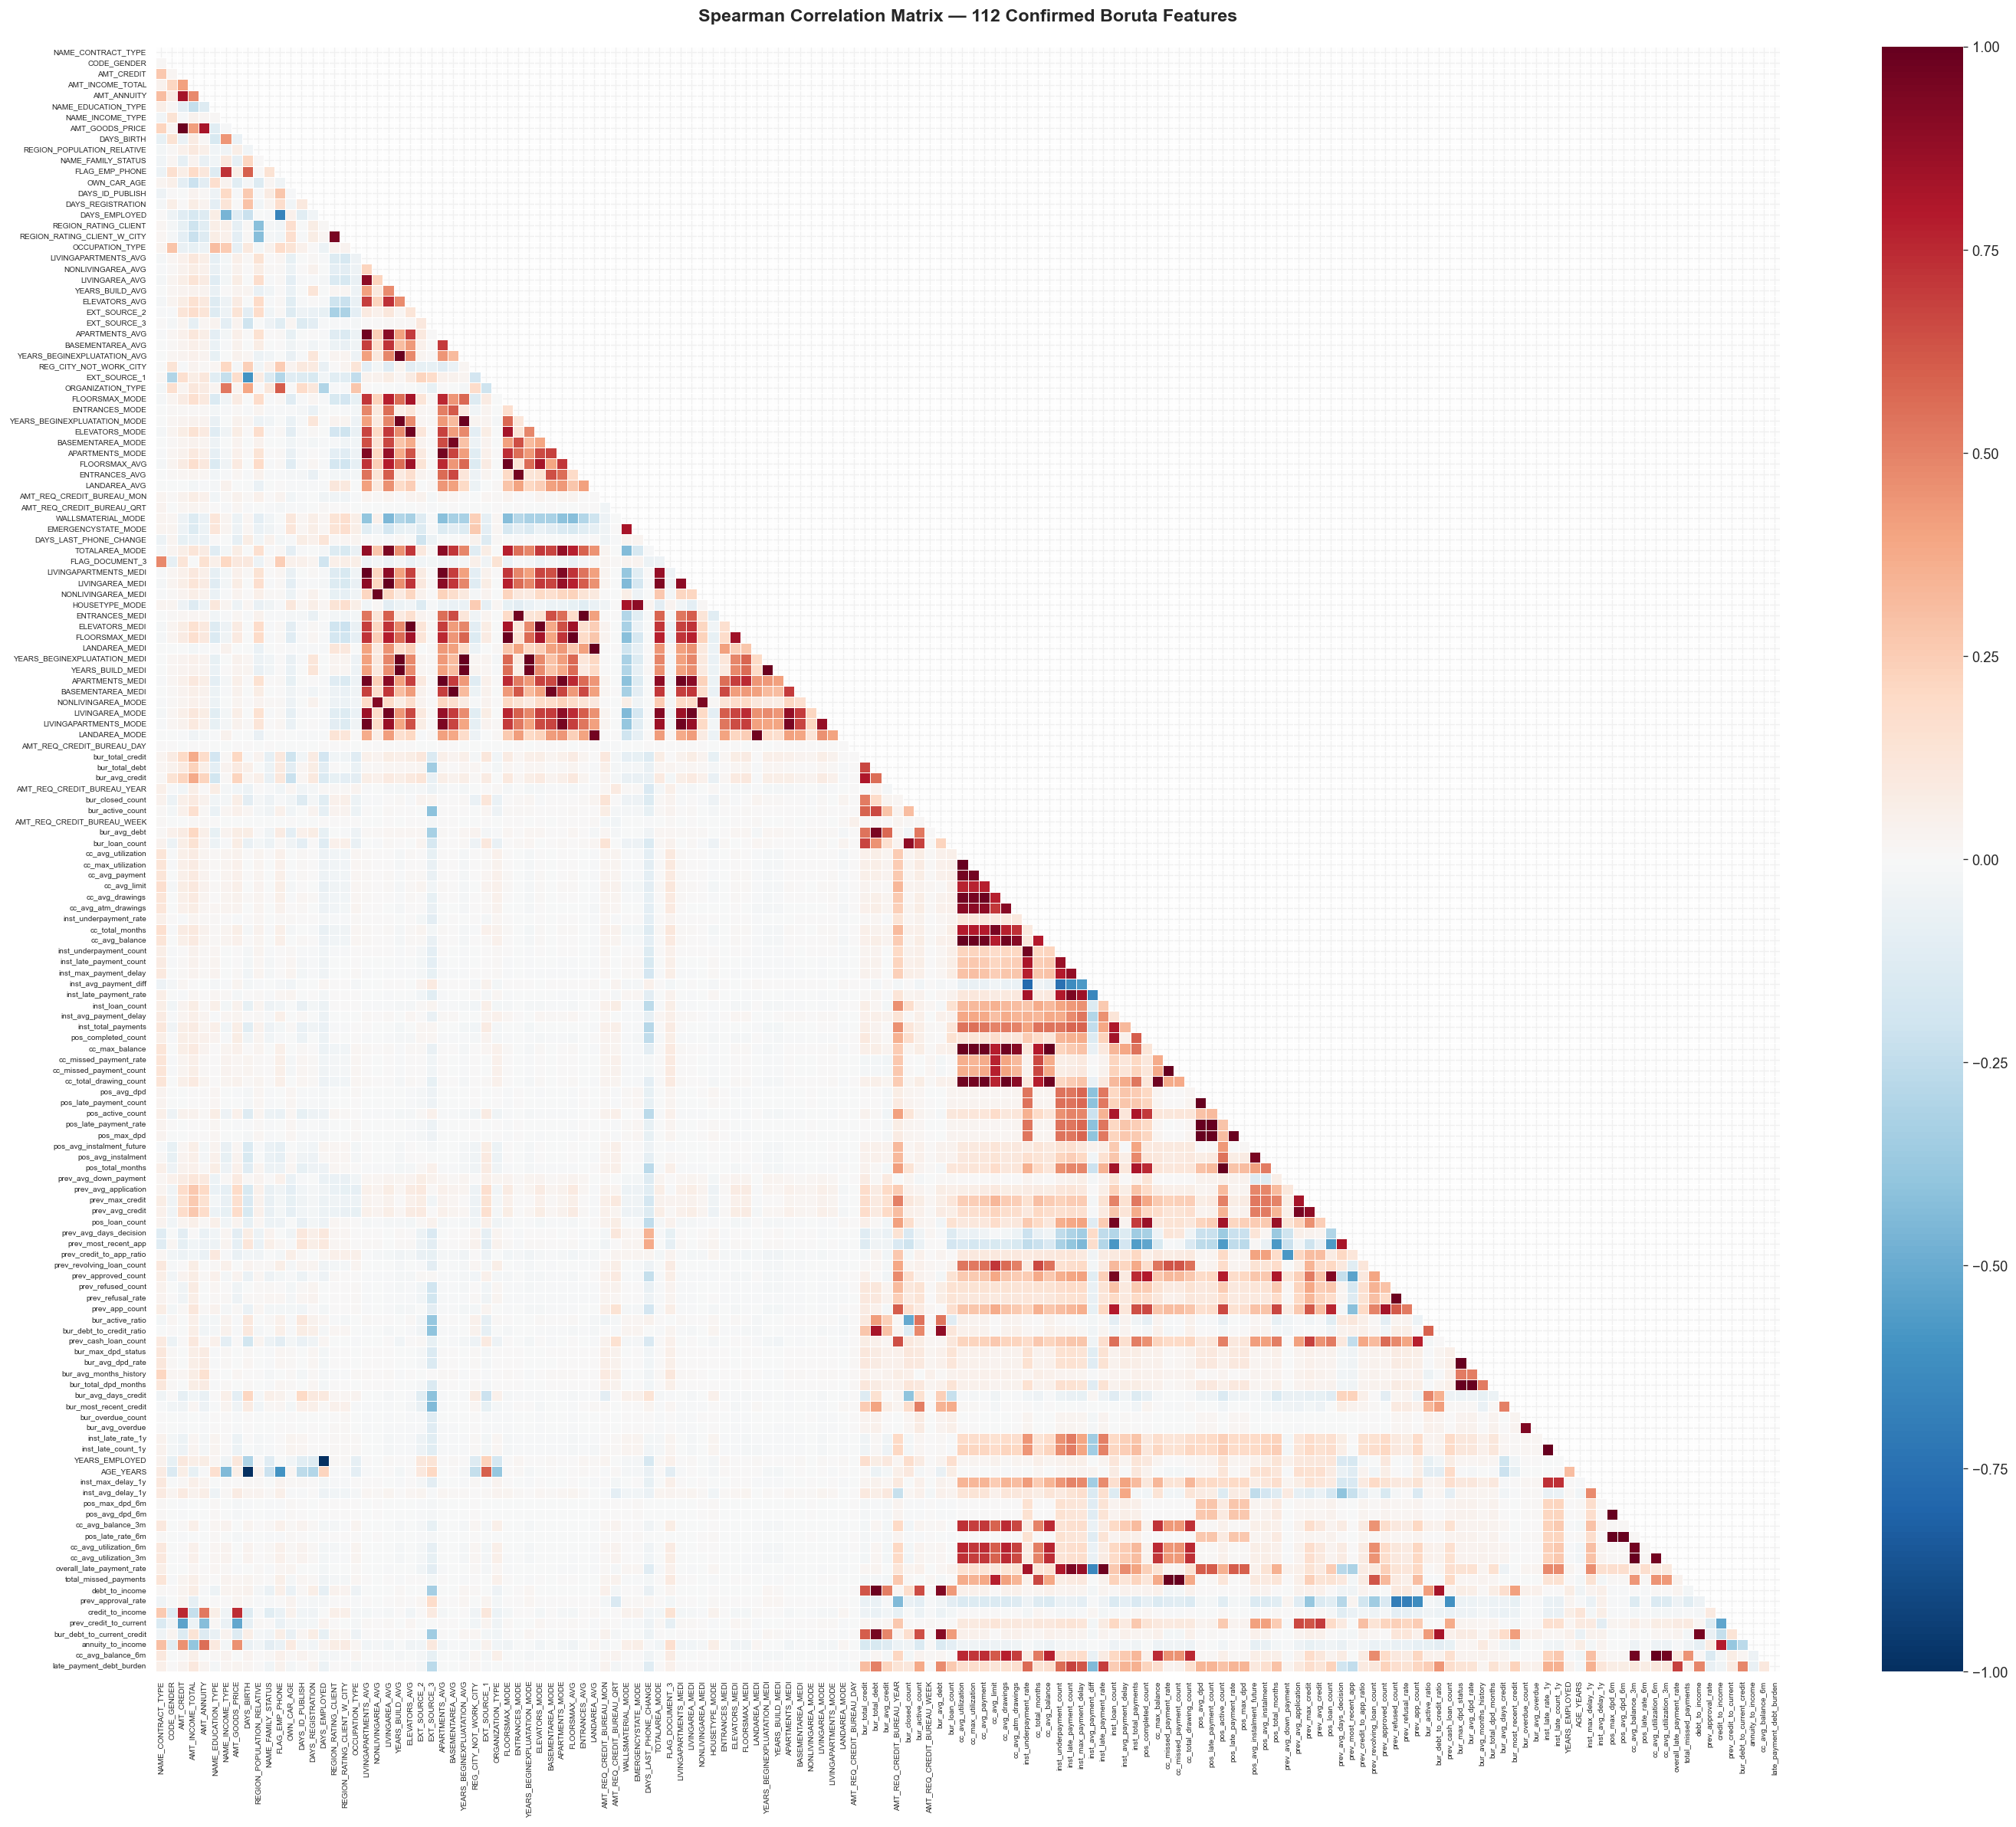

In [36]:
# Get confirmed feature columns that exist in df
confirmed_cols = confirmed['Feature'].tolist()
corr_df = df[confirmed_cols].copy()

# Compute correlation matrix
corr_matrix = corr_df.corr(method='spearman')

# Plot
fig, ax = plt.subplots(figsize=(24, 20))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.3,
    ax=ax,
    xticklabels=True,
    yticklabels=True,
    annot=False  # 112x112 is too large for annotations
)

ax.set_title('Spearman Correlation Matrix — 112 Confirmed Boruta Features', 
             fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=90, fontsize=6)
plt.yticks(rotation=0, fontsize=6)
plt.tight_layout()
plt.show()

In [37]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
# Prepare data — drop nulls for VIF calculation
vif_df = df[confirmed_cols].fillna(-999).select_dtypes(include=[np.number])

# Compute VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = vif_df.columns
vif_data['VIF'] = [variance_inflation_factor(vif_df.values, i) 
                   for i in range(vif_df.shape[1])]

vif_data = vif_data.sort_values('VIF', ascending=False)

print(f"Features with VIF > 10 (high multicollinearity):")
print(vif_data[vif_data['VIF'] > 10].to_string())
print(f"\nFeatures with VIF 5-10 (moderate):")
print(vif_data[(vif_data['VIF'] >= 5) & (vif_data['VIF'] <= 10)].to_string())
print(f"\nFeatures with VIF < 5 (acceptable):")
print(f"Count: {len(vif_data[vif_data['VIF'] < 5])}")

Features with VIF > 10 (high multicollinearity):
                          Feature           VIF
8                      DAYS_BIRTH           inf
131                     AGE_YEARS           inf
22                YEARS_BUILD_AVG  5.350981e+10
57               YEARS_BUILD_MEDI  5.350949e+10
48          LIVINGAPARTMENTS_MEDI  4.075361e+10
19           LIVINGAPARTMENTS_AVG  3.544760e+10
52                 ENTRANCES_MEDI  2.919713e+10
28    YEARS_BEGINEXPLUATATION_AVG  2.726670e+10
39                  ENTRANCES_AVG  2.576592e+10
59              BASEMENTAREA_MEDI  2.545852e+10
58                APARTMENTS_MEDI  2.471362e+10
26                 APARTMENTS_AVG  2.191853e+10
56   YEARS_BEGINEXPLUATATION_MEDI  2.188721e+10
27               BASEMENTAREA_AVG  2.127847e+10
50             NONLIVINGAREA_MEDI  1.958696e+10
55                  LANDAREA_MEDI  1.880115e+10
53                 ELEVATORS_MEDI  1.864266e+10
49                LIVINGAREA_MEDI  1.709967e+10
21                 LIVINGAREA_AVG  1.51

In [38]:
print(X_boruta.min().min())  # should be -999
print(X_boruta.isnull().sum().sum())  # should be 0

-2176471.75
0


In [39]:
# Find which column has the extreme minimum
print(X_boruta.min().sort_values().head(20))

bur_total_debt             -2.176472e+06
bur_avg_debt               -3.109246e+05
late_payment_debt_burden   -2.048752e+05
inst_avg_payment_diff      -1.461459e+05
DAYS_BIRTH                 -2.520100e+04
DAYS_REGISTRATION          -2.467200e+04
DAYS_EMPLOYED              -1.791200e+04
DAYS_ID_PUBLISH            -7.197000e+03
DAYS_LAST_PHONE_CHANGE     -4.292000e+03
prev_most_recent_app       -2.922000e+03
bur_most_recent_credit     -2.922000e+03
prev_avg_days_decision     -2.922000e+03
bur_avg_days_credit        -2.922000e+03
cc_avg_balance             -1.193055e+03
NONLIVINGAREA_AVG          -9.990000e+02
OWN_CAR_AGE                -9.990000e+02
ENTRANCES_AVG              -9.990000e+02
FLOORSMAX_AVG              -9.990000e+02
FLOORSMIN_AVG              -9.990000e+02
LANDAREA_AVG               -9.990000e+02
dtype: float64


In [50]:
# Keep AGE_YEARS and YEARS_EMPLOYED (more interpretable)
# Drop the raw days versions
drop_perfect = ['DAYS_BIRTH', 'DAYS_EMPLOYED']

drop_building = [c for c in confirmed_cols 
                 if (c.endswith('_MODE') or c.endswith('_MEDI'))
                 and c.replace('_MODE','_AVG').replace('_MEDI','_AVG') in confirmed_cols]

drop_redundant = [
    'overall_late_payment_rate',
    'inst_late_payment_count',
    'inst_underpayment_count',
    'inst_late_count_1y',
    'prev_refused_count',
    'prev_approved_count',
    'bur_active_count',
    'bur_closed_count',
    'pos_active_count',
    'pos_completed_count',
    'pos_late_payment_count',
    'inst_total_payments',
    'cc_avg_balance',
    'cc_avg_utilization',
    'cc_missed_payment_count',  # rate exists
    'total_missed_payments',    # composite of existing counts
    'prev_cash_loan_count',     # prev_app_count covers volume
    'REGION_RATING_CLIENT',     # W_CITY version more specific
    'AMT_GOODS_PRICE',          # ~0.99 corr with AMT_CREDIT
]

all_drops = drop_perfect + drop_building + drop_redundant
final_features = [f for f in confirmed_cols if f not in all_drops]
print(f"Reduced from 150 to {len(final_features)} features")

Reduced from 150 to 108 features


In [53]:
all_drops = drop_perfect + drop_building + drop_redundant

final_features = [f for f in confirmed_cols if f not in all_drops]
print(f"Reduced from 150 to {len(final_features)} features")

Reduced from 150 to 108 features


In [54]:
# Prepare data — drop nulls for VIF calculation
vif_df_final = df[final_features].fillna(-999).select_dtypes(include=[np.number])

# Compute VIF for each feature
vif_data = pd.DataFrame()
vif_data['Feature'] = vif_df_final.columns
vif_data['VIF'] = [variance_inflation_factor(vif_df_final.values, i) 
                   for i in range(vif_df_final.shape[1])]

vif_data = vif_data.sort_values('VIF', ascending=False)

print(f"Features with VIF > 10 (high multicollinearity):")
print(vif_data[vif_data['VIF'] > 10].to_string())
print(f"\nFeatures with VIF 5-10 (moderate):")
print(vif_data[(vif_data['VIF'] >= 5) & (vif_data['VIF'] <= 10)].to_string())
print(f"\nFeatures with VIF < 5 (acceptable):")
print(f"Count: {len(vif_data[vif_data['VIF'] < 5])}")

Features with VIF > 10 (high multicollinearity):
                         Feature           VIF
63         pos_late_payment_rate  1.659375e+07
56        inst_late_payment_rate  1.531074e+07
82              bur_avg_dpd_rate  1.281672e+07
87             bur_overdue_count  9.591228e+06
52        inst_underpayment_rate  8.188355e+06
39     AMT_REQ_CREDIT_BUREAU_DAY  3.935271e+06
47            cc_max_utilization  3.822986e+06
44    AMT_REQ_CREDIT_BUREAU_WEEK  3.533030e+06
77             prev_refusal_rate  3.094061e+06
79              bur_active_ratio  2.689727e+06
101           prev_approval_rate  2.472318e+06
60        cc_missed_payment_rate  1.284615e+06
80      bur_debt_to_credit_ratio  1.037792e+06
72                pos_loan_count  1.031290e+06
57               inst_loan_count  9.944577e+05
81            bur_max_dpd_status  8.617083e+05
103       prev_credit_to_current  4.535674e+05
32     AMT_REQ_CREDIT_BUREAU_QRT  2.516120e+05
31     AMT_REQ_CREDIT_BUREAU_MON  1.911259e+05
76     prev

In [55]:
# Drop the obvious remaining pairs
drop_round2 = [
    'AMT_GOODS_PRICE',        # ~0.99 corr with AMT_CREDIT
    'REGION_RATING_CLIENT',   # W_CITY version is more specific
    'cc_avg_balance_3m',      # keep 6m — longer window more stable
    'cc_avg_utilization_3m',  # keep 6m
    'pos_avg_instalment',     # pos_avg_instalment_future covers this
    'TOTALAREA_MODE',         # covered by APARTMENTS_AVG + LIVINGAREA_AVG
    'FLOORSMAX_AVG',          # weak credit signal
    'ENTRANCES_AVG',          # weak credit signal
    'ELEVATORS_AVG',          # weak credit signal
    'YEARS_BEGINEXPLUATATION_AVG',  # weak credit signal
    'BASEMENTAREA_AVG',       # weak credit signal
    'LANDAREA_AVG',           # weak credit signal
    'NONLIVINGAREA_AVG',      # weak credit signal
    'LIVINGAREA_AVG',         # weak credit signal
    'APARTMENTS_AVG',         # weak credit signal
]

lr_svm_features = [f for f in final_features if f not in drop_round2]
print(f"LR/SVM feature count: {len(lr_svm_features)}")

LR/SVM feature count: 95


In [56]:
# Full set — for XGBoost, RF, ANN
full_feature_set = final_features
print(f"Full feature set: {len(full_feature_set)}")

# Reduced set — for LR and SVM
reduced_feature_set = lr_svm_features
print(f"Reduced feature set: {len(reduced_feature_set)}")

import json

with open('C:/Users/BeratErcan/Home-Credit-Default-Risk/src/feature_sets.json', 'w') as f:
    json.dump({
        'full': full_feature_set,
        'reduced': reduced_feature_set
    }, f, indent=2)

print("Saved successfully")
print(f"Full features: {len(full_feature_set)}")
print(f"Reduced features: {len(reduced_feature_set)}")

Full feature set: 108
Reduced feature set: 95
Saved successfully
Full features: 108
Reduced features: 95


#### NULL HANDLING


In [57]:
df_model = df[full_feature_set + ['TARGET']].copy()

# Check current null situation
print(f"Total nulls: {df_model.isnull().sum().sum()}")
print(df_model.isnull().sum()[df_model.isnull().sum() > 0].sort_values(ascending=False))

Total nulls: 4112665
LIVINGAPARTMENTS_AVG      210199
YEARS_BUILD_AVG           204488
OWN_CAR_AGE               202929
LANDAREA_AVG              182590
BASEMENTAREA_AVG          179943
                           ...  
pos_total_months           16454
EXT_SOURCE_2                 660
AMT_ANNUITY                   12
annuity_to_income             12
DAYS_LAST_PHONE_CHANGE         1
Length: 77, dtype: int64


In [58]:
# Group 1 — No history = 0 activity
zero_fill_cols = [c for c in df_model.columns if c.startswith((
    'bur_', 'pos_', 'inst_', 'cc_', 'prev_'
))]
df_model[zero_fill_cols] = df_model[zero_fill_cols].fillna(0)

# Group 2 — Cross-table ratio features
# If underlying values were 0, ratio should be 0 too
ratio_cols = ['debt_to_income', 'annuity_to_income', 'credit_to_income',
              'late_payment_debt_burden', 'bur_debt_to_current_credit']
df_model[ratio_cols] = df_model[ratio_cols].fillna(0)

# Group 3 — Building/apartment features — median imputation
building_cols = ['LANDAREA_AVG', 'BASEMENTAREA_AVG', 'NONLIVINGAREA_AVG',
                 'ELEVATORS_AVG', 'APARTMENTS_AVG', 'ENTRANCES_AVG',
                 'LIVINGAREA_AVG', 'FLOORSMAX_AVG', 'YEARS_BEGINEXPLUATATION_AVG',
                 'TOTALAREA_MODE']
for col in building_cols:
    df_model[col] = df_model[col].fillna(df_model[col].median())

# Group 4 — EXT_SOURCE — median imputation
ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
for col in ext_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].fillna(df_model[col].median())

# Group 5 — Small nulls — median imputation
small_null_cols = ['AMT_GOODS_PRICE', 'AMT_ANNUITY', 'annuity_to_income',
                   'DAYS_LAST_PHONE_CHANGE', 'YEARS_EMPLOYED',
                   'prev_avg_down_payment', 'prev_credit_to_app_ratio']
for col in small_null_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].fillna(df_model[col].median())

# Verify
remaining = df_model.isnull().sum().sum()
print(f"Remaining nulls: {remaining}")
print(df_model.isnull().sum()[df_model.isnull().sum() > 0])

Remaining nulls: 825211
OWN_CAR_AGE                   202929
LIVINGAPARTMENTS_AVG          210199
YEARS_BUILD_AVG               204488
AMT_REQ_CREDIT_BUREAU_MON      41519
AMT_REQ_CREDIT_BUREAU_QRT      41519
AMT_REQ_CREDIT_BUREAU_DAY      41519
AMT_REQ_CREDIT_BUREAU_YEAR     41519
AMT_REQ_CREDIT_BUREAU_WEEK     41519
dtype: int64


In [60]:
# New columns not covered by previous null handling

# OWN_CAR_AGE — no car = 0 years
df_model['OWN_CAR_AGE'] = df_model['OWN_CAR_AGE'].fillna(0)

# Building features not previously covered
new_building_cols = ['LIVINGAPARTMENTS_AVG', 'YEARS_BUILD_AVG']
for col in new_building_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].fillna(df_model[col].median())

# AMT_REQ_CREDIT_BUREAU_* — credit bureau enquiry counts
# Fill with 0 — no enquiries recorded means 0 enquiries
bureau_req_cols = [c for c in df_model.columns if c.startswith('AMT_REQ_CREDIT_BUREAU')]
df_model[bureau_req_cols] = df_model[bureau_req_cols].fillna(0)

# Verify
print(f"Remaining nulls: {df_model.isnull().sum().sum()}")
print(df_model.isnull().sum()[df_model.isnull().sum() > 0])

Remaining nulls: 0
Series([], dtype: int64)


In [61]:
import os
df_model.to_parquet(
    'C:/Users/BeratErcan/Home-Credit-Default-Risk/data/processed/df_model.parquet',
    index=False,
    compression='snappy'
)

size = os.path.getsize('C:/Users/BeratErcan/Home-Credit-Default-Risk/data/processed/df_model.parquet') / (1024*1024)
print(f"Size: {size:.1f} MB")
print(f"Shape: {df_model.shape}")

Size: 46.6 MB
Shape: (307511, 109)
